# Calculate model tuning to stimulus identity during maintenance

Using multiload models  

Start by calculating whether there are neurons tuned to a particular stimulus during the maintenance period during load 1  

Then check in load-3 whether these neurons remain tuned


In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-06-09 12:19:09.187401: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 12:19:09.195531: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-09 12:19:09.204277: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-09 12:19:09.206937: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-09 12:19:09.214079: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# the two models with > 0.7 accuracy are:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [3]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_paths = ld.find_files(all_models_dir, '*N_1000*.mat')
model_names = [os.path.basename(m)[:-4] for m in model_paths]
print(len(model_names))
print(model_names)

8
['Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_155940', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_17_140925', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058']


## Stim-selectivity

### nonparametric version

Loaded behavioral variables from other_variables


Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

Loaded behavioral variables from other_variables


Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

Loaded behavioral variables from other_variables


...

Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

Loaded behavioral variables from other_variables


Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

Loaded behavioral variables from other_variables


Stim1 tuning (nonparametric):   0%|          | 0/1000 [00:00<?, ?it/s]

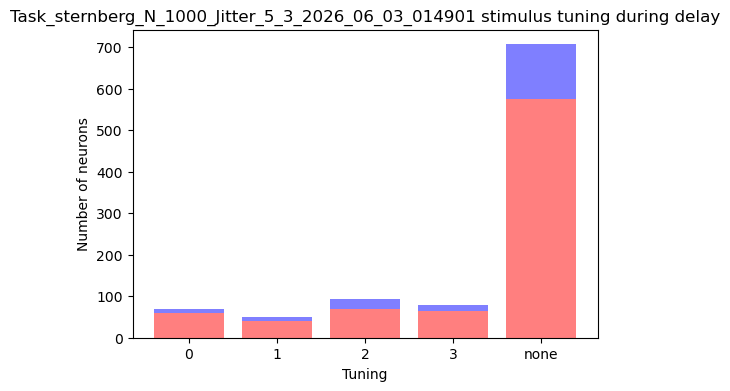

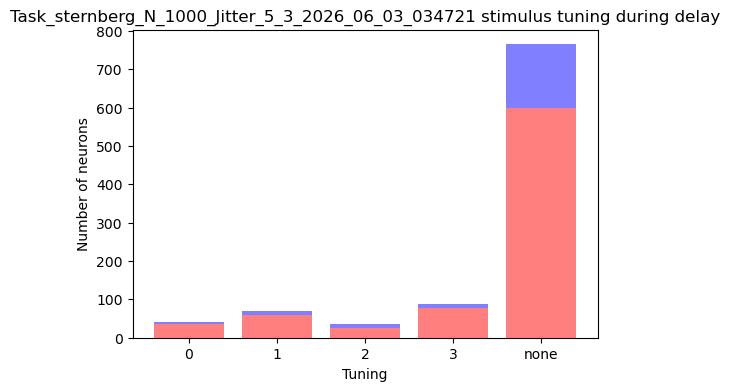

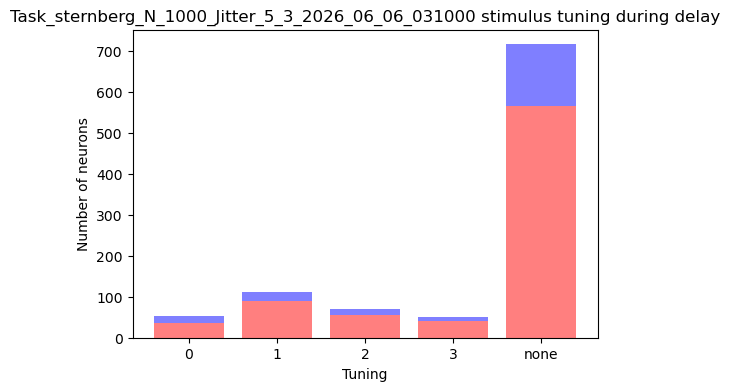

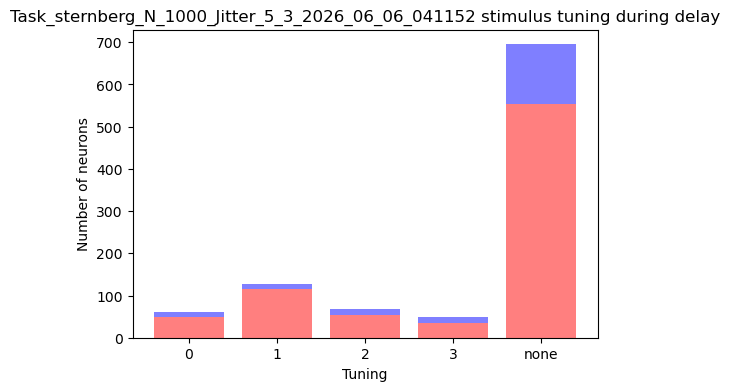

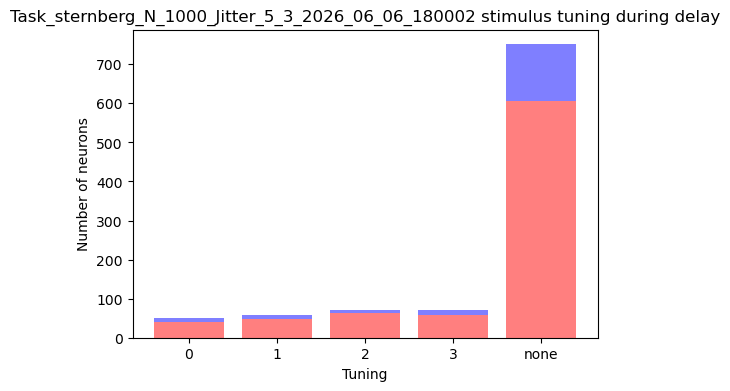

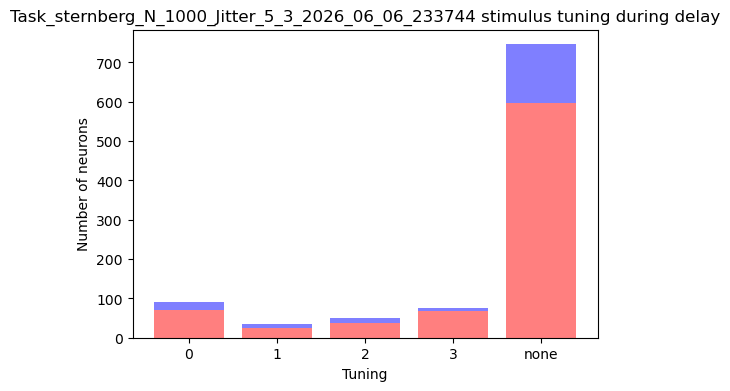

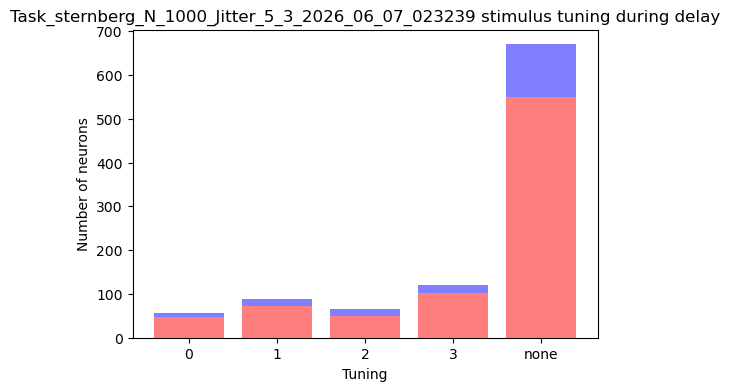

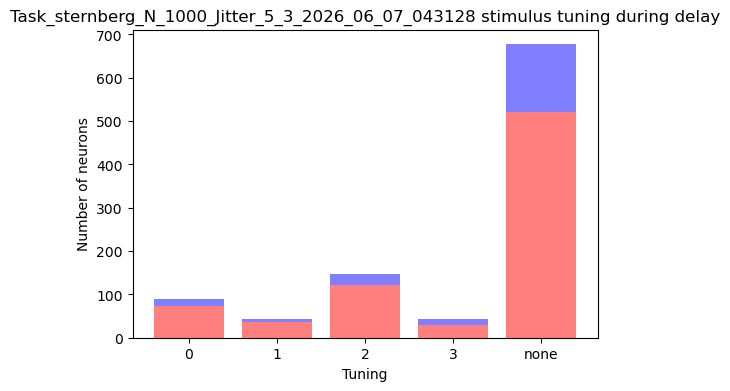

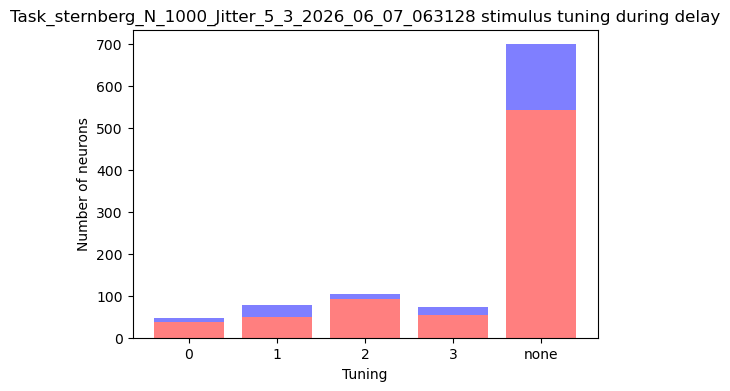

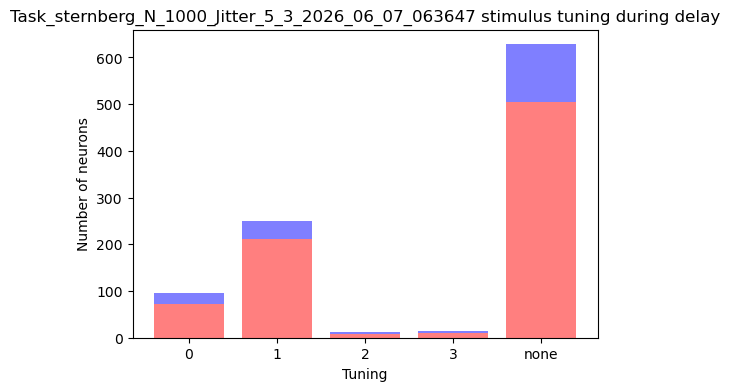

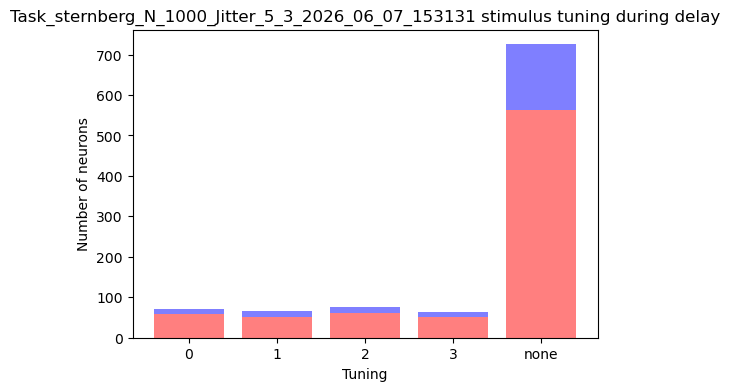

In [ ]:
# USING BALANCE STIM
importlib.reload(rn)

for i, model_name in enumerate(model_names):
    
    model_dir = os.path.join(all_models_dir, model_name)
    save_path = os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz')
    if os.path.exists(save_path):
        print(f'Tuning file already exists for {model_name}, skipping...')
        continue
    
    # neural data
    _, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                                all_models_dir = all_models_dir, load_LFP=False)
    
    settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num, 
                                        other_labels="balance_stim",
                                        all_models_dir=all_models_dir)

    # behavioral data
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_stim",
                                                        all_models_dir=all_models_dir)

    # turn all inf into nans
    trial_labels = np.nan_to_num(trial_labels, nan=np.inf)
    trial_perfs = np.nan_to_num(trial_perfs, nan=np.inf)
    trial_outputs = np.nan_to_num(trial_outputs, nan=np.inf)
    
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    bhv_vars = {'trial_labels': trial_labels, 'trial_perfs': trial_perfs, 'trial_outputs': trial_outputs}
    tuning = rn.calc_stim1_tuning_nonparametric(model_name, condn_phrase, condn_num, other_labels = "balance_stim",
                        rates_data=rates_data, other_variables=bhv_vars, period='delay',
                        kw_alpha=0.05, dunn_alpha=0.05, dunn_p_adjust='holm',
                        use_prescreen=True, prescreen_alpha=0.20,
                        show_progress=True, all_models_dir=all_models_dir)

    rn.plot_stim1_tuning(tuning, exc_ind=exc_ind, title=f'{model_name} stimulus tuning during delay', ax=None)

    # save tuning to the model folder as stim1_tuning.npz
    np.savez(save_path, stim1_tuning=tuning)

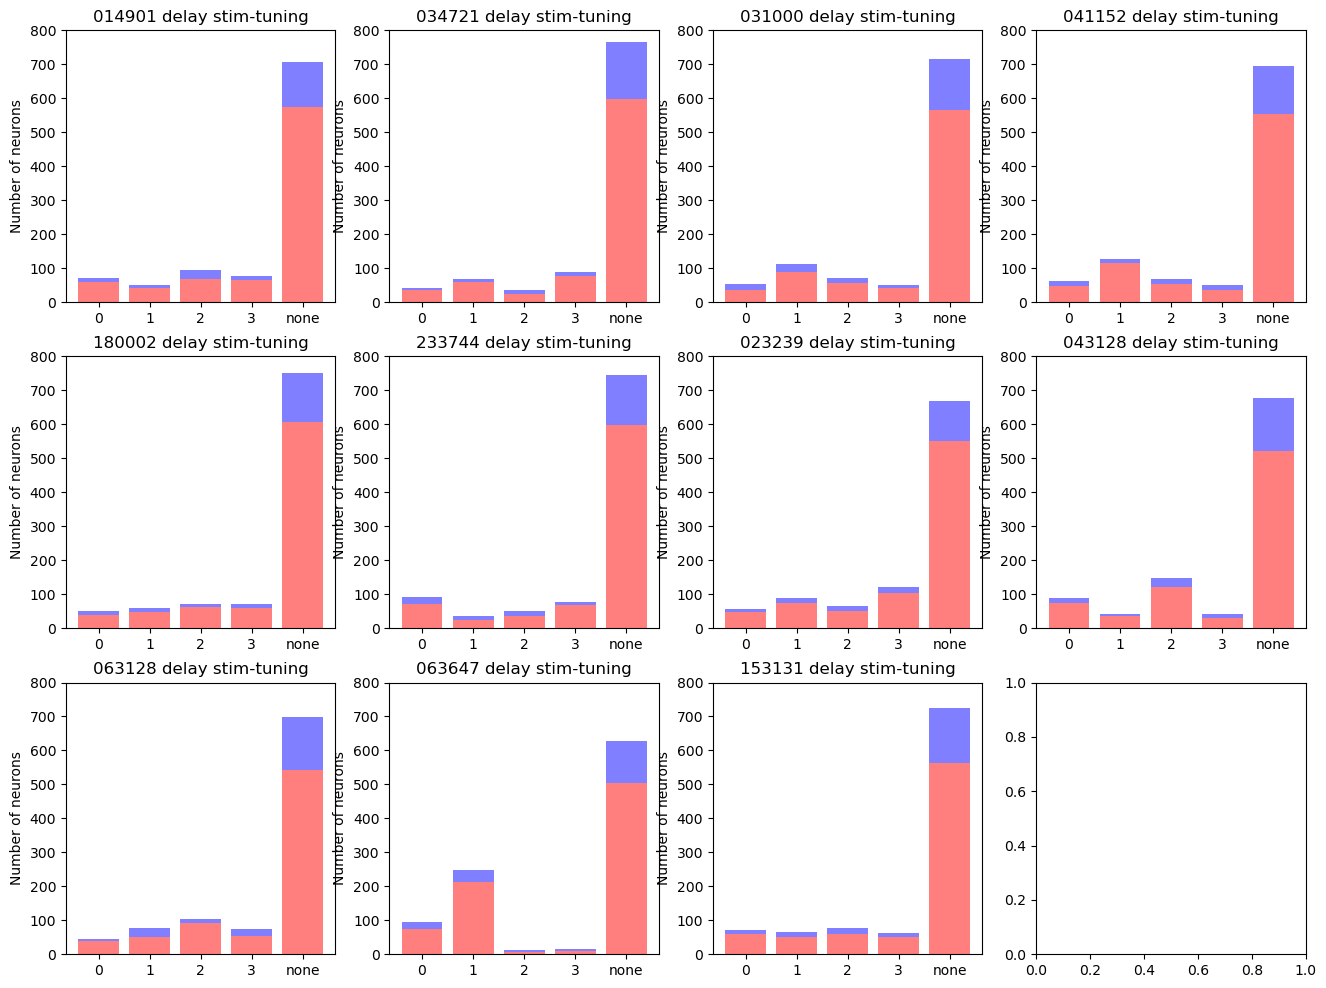

In [6]:
tuning_names = ['stim1_tuning_duringdelay_nonparametric.npz']
label_name = ['nonparametric']

for i, tuning_name in enumerate(tuning_names):
    fig, ax = plt.subplots(3, 4, figsize=(16,12))
    ax = ax.flatten()
    for j, model_name in enumerate(model_names):
        model_dir = os.path.join(all_models_dir, model_name)
        save_path = os.path.join(model_dir, tuning_name)
        tuning = np.load(save_path)['stim1_tuning']
        exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
        
        rn.plot_stim1_tuning(tuning, exc_ind=exc_ind, title=f'{model_name[-6:]} delay stim-tuning', ax=ax[j])
        ax[j].set_ylim([0, 800])
        ax[j].set_xlabel('')
        
plt.show()

### firing rate plots

#### separated by maintenance preferance identity

(780, 1000, 450)


/tmp/ipykernel_335681/1553869892.py:51: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_335681/1553869892.py:52: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
/tmp/ipykernel_335681/1553869892.py:52: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


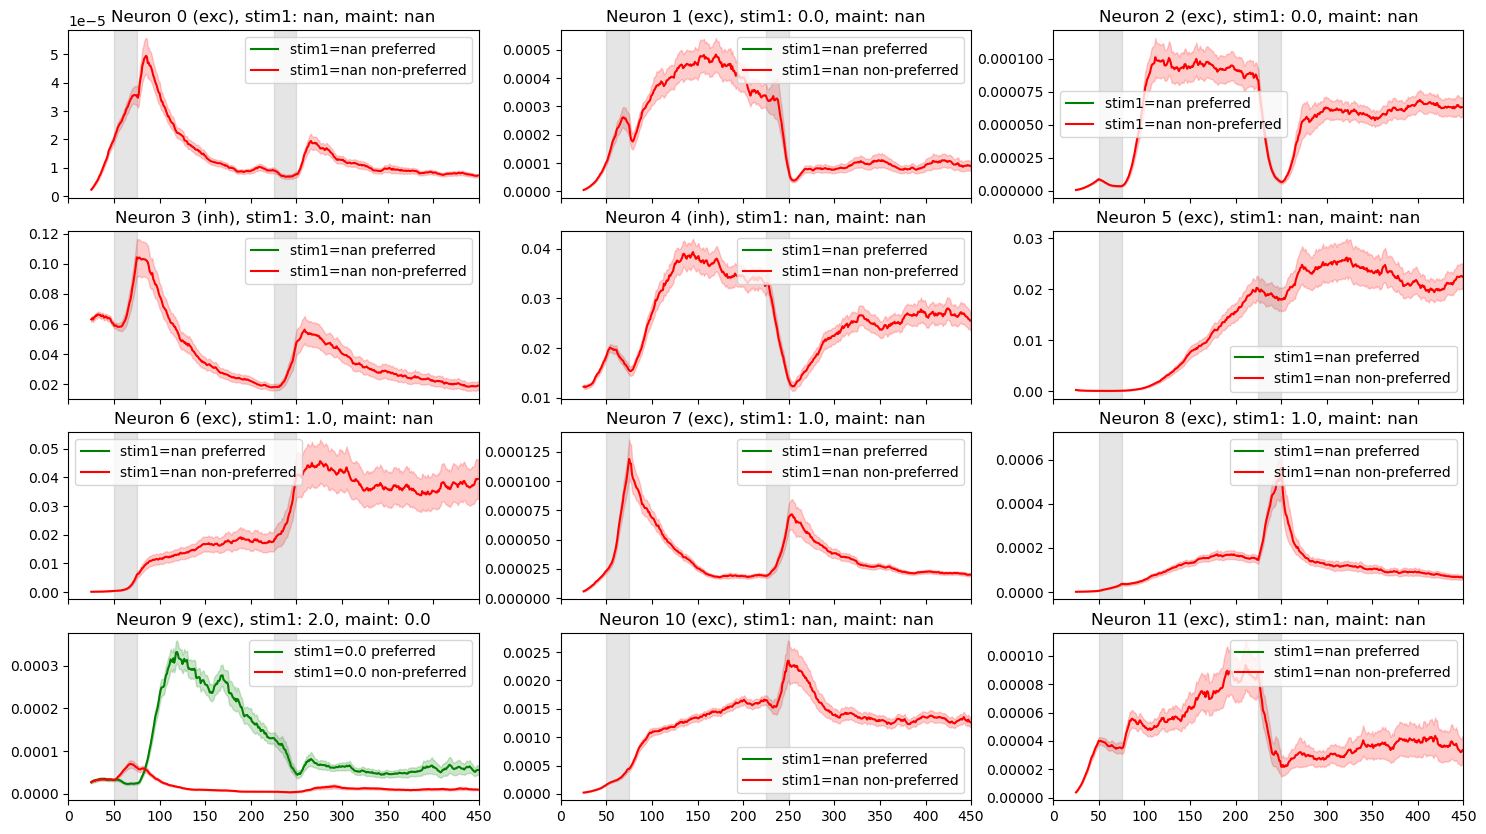

In [7]:
# sanity check -- for one model, plot examples of tuned neurons -- LOAD 1
# plot mean across the trial type
# split by match/mismatch

model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
load = 1
# plot a few examples of tuned neurons
fig, axs = plt.subplots(4, 3, figsize=(18,10), sharex=True)
axs = axs.flatten()
colors = ['g','r']
for neuron_idx in range(12):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot load1 trial for stim1=preferred, and stim1=nonpreferred
    trial_idxs_pref = np.where(np.all(trial_labels[:,[0,2]] == [load, neuron_tuning], axis=1))[0]
    trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & (trial_labels[:,2] != neuron_tuning))[0]
    for j, trial_idxs in enumerate([trial_idxs_pref, trial_idxs_nonpref]):
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'stim1={neuron_tuning} {["preferred","non-preferred"][j]}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inh", "exc"][is_exc]}), stim1: {stim1_stimtuning[neuron_idx]}, maint: {maint_stimtuning[neuron_idx]}')

    ax.legend()

(780, 1000, 450)


/tmp/ipykernel_335681/1023373912.py:53: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_335681/1023373912.py:54: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
/tmp/ipykernel_335681/1023373912.py:54: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


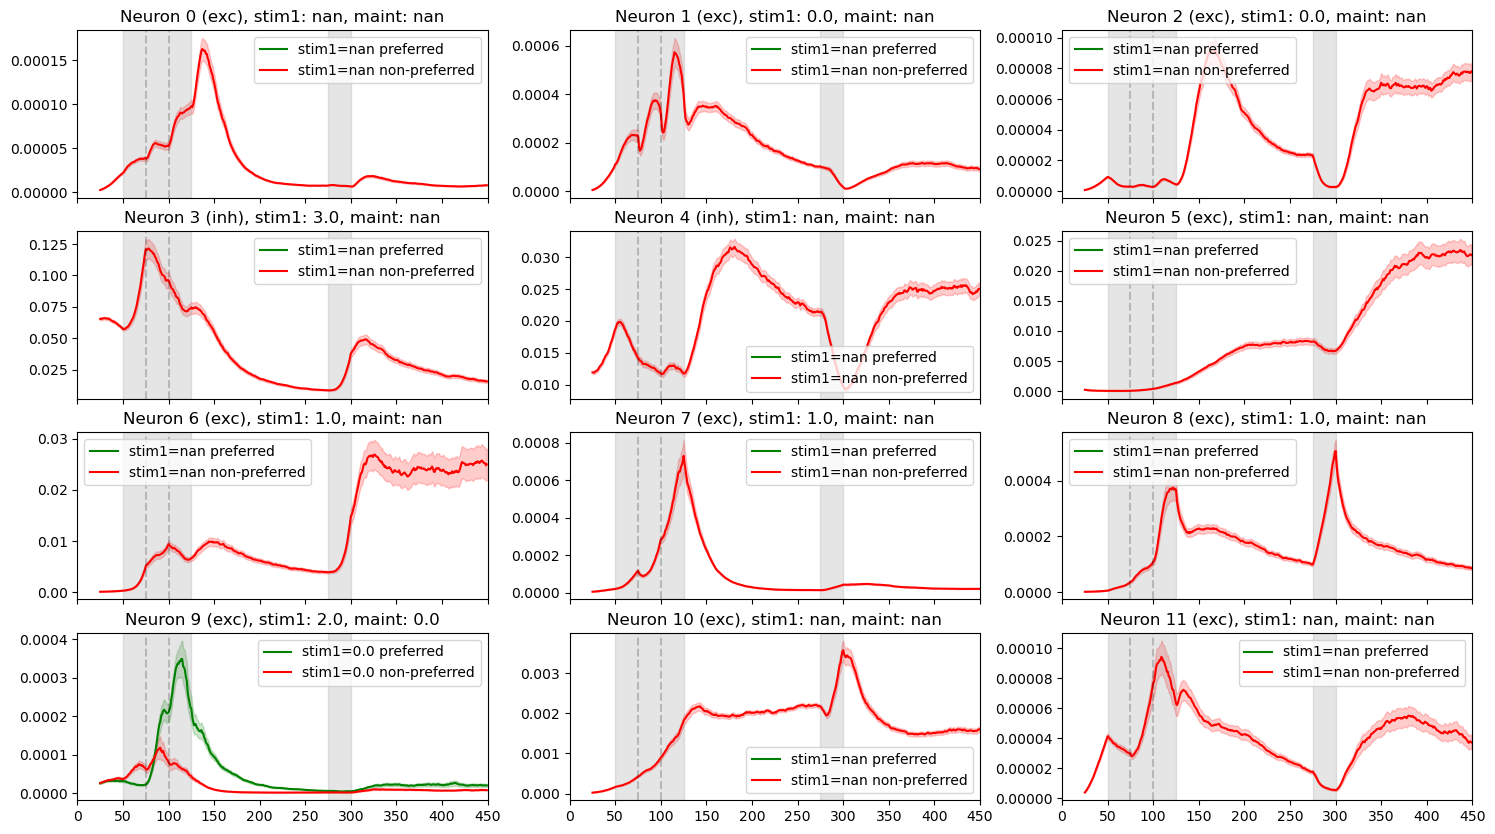

In [8]:
# sanity check -- for one model, plot examples of tuned neurons  -- LOAD 3, stim1 specified
# plot mean across the trial type
# split by match/mismatch

model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
load = 3
# plot a few examples of tuned neurons
fig, axs = plt.subplots(4, 3, figsize=(18,10), sharex=True)
axs = axs.flatten()
colors = ['g','r']
for neuron_idx in range(12):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot load-3 trial for stim1=preferred and stim2/3=nonpreferred, and stim1/2/3=nonpreferred
    trial_idxs_pref = np.where(np.all(trial_labels[:,[0,2]] == [load, neuron_tuning], axis=1) & # stim1 is preferred
                               np.all(trial_labels[:,[3,4]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim2/3 are non-preferred
    trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & # correct load
                                  np.all(trial_labels[:,[2,3,4]] != [neuron_tuning, neuron_tuning, neuron_tuning], axis=1))[0] # stim1/2/3 are non-preferred
    for j, trial_idxs in enumerate([trial_idxs_pref, trial_idxs_nonpref]):
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'stim1={neuron_tuning} {["preferred","non-preferred"][j]}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inh", "exc"][is_exc]}), stim1: {stim1_stimtuning[neuron_idx]}, maint: {maint_stimtuning[neuron_idx]}')
    ax.legend()

(780, 1000, 450)


/tmp/ipykernel_335681/4044249904.py:57: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_335681/4044249904.py:58: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
/tmp/ipykernel_335681/4044249904.py:58: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


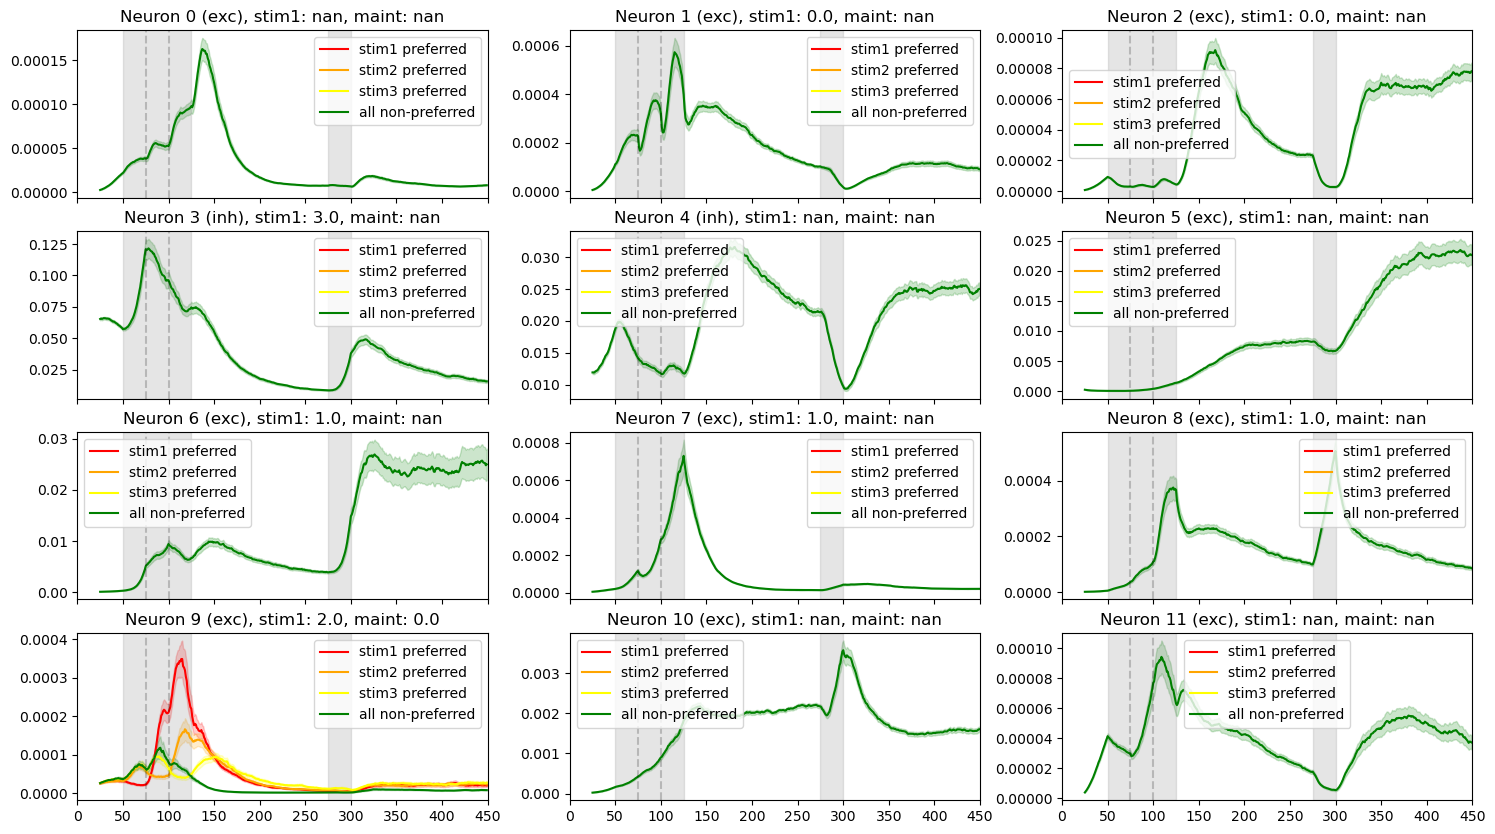

In [9]:
# sanity check -- for one model, plot examples of tuned neurons  -- LOAD 3, stim2 specified
# plot mean across the trial type
# split by match/mismatch

model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']

stim1_tuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
load = 3
# plot a few examples of tuned neurons
fig, axs = plt.subplots(4, 3, figsize=(18,10), sharex=True)
axs = axs.flatten()
colors = ['r','orange', 'yellow', 'g']
for neuron_idx in range(12):
    ax = axs[neuron_idx]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot load-3 trial for stim1/2/3=preferred and rest=nonpreferred, and stim1/2/3=nonpreferred
    trial_idxs_pref1 = np.where(np.all(trial_labels[:,[0,2]] == [load, neuron_tuning], axis=1) & # stim1 is preferred
                               np.all(trial_labels[:,[3,4]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim2/3 are non-preferred
    trial_idxs_pref2 = np.where(np.all(trial_labels[:,[0,3]] == [load, neuron_tuning], axis=1) & # stim2 is preferred
                               np.all(trial_labels[:,[2,4]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim1/3 are non-preferred
    trial_idxs_pref3 = np.where(np.all(trial_labels[:,[0,4]] == [load, neuron_tuning], axis=1) & # stim3 is preferred
                               np.all(trial_labels[:,[2,3]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim1/2 are non-preferred
    trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & # correct load
                                  np.all(trial_labels[:,[2,3,4]] != [neuron_tuning, neuron_tuning, neuron_tuning], axis=1))[0] # stim1/2/3 are non-preferred
    for j, trial_idxs in enumerate([trial_idxs_pref1, trial_idxs_pref2, trial_idxs_pref3, trial_idxs_nonpref]):
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        if j < 3:
            ax.plot(mean_rate, label=f'stim{["1","2","3"][j]} preferred', color = colors[j])
        else:
            ax.plot(mean_rate, label=f'all non-preferred', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inh", "exc"][is_exc]}), stim1: {stim1_stimtuning[neuron_idx]}, maint: {maint_stimtuning[neuron_idx]}')
    ax.legend()

#### general preferences of these neurons

121 neurons are nan for stim1 tuning but non-nan for maintenance tuning
399 neurons are nan for maintenance tuning but non-nan for stim1 tuning
308 neurons are nan for both stim1 and maintenance tuning
104 neurons have matching stim1 and maintenance tuning and are both tuned
68 neurons have non-matching stim1 and maintenance tuning and are both tuned


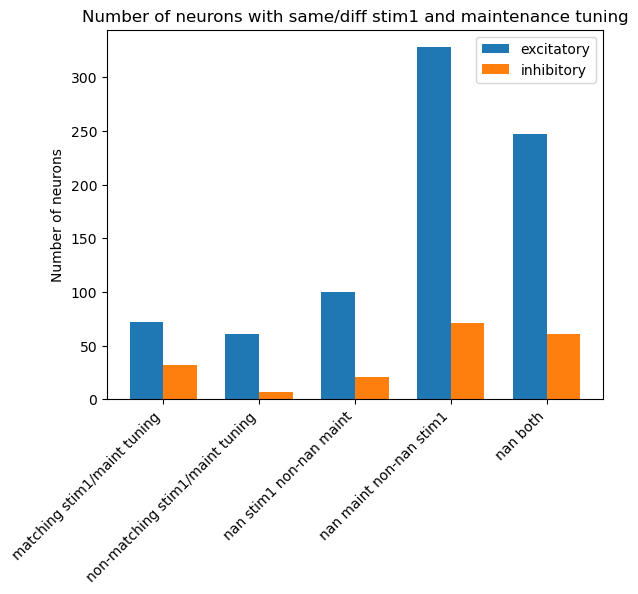

In [10]:
# check if stim1 stim-tuning and maintenance stim-tuning match

model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)
stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']

matching_idx = np.where(stim1_stimtuning == maint_stimtuning)[0]
nonmatching_idx = np.where(stim1_stimtuning != maint_stimtuning)[0]
# print(f'{len(matching_idx)} neurons have matching stim1 and maintenance tuning')
# print(f'{len(nonmatching_idx)} neurons have non-matching stim1 and maintenance tuning')

# how many are nan for one and non-nan for the other
nan_stim1 = np.where(np.isnan(stim1_stimtuning))[0]
nan_maint = np.where(np.isnan(maint_stimtuning))[0]
nan_stim1_non_nan_maint = np.intersect1d(nan_stim1, np.setdiff1d(np.arange(len(stim1_stimtuning)), nan_maint))
nan_maint_non_nan_stim1 = np.intersect1d(nan_maint, np.setdiff1d(np.arange(len(maint_stimtuning)), nan_stim1))
print(f'{len(nan_stim1_non_nan_maint)} neurons are nan for stim1 tuning but non-nan for maintenance tuning')
print(f'{len(nan_maint_non_nan_stim1)} neurons are nan for maintenance tuning but non-nan for stim1 tuning')

# how many are both nan
nan_both = np.intersect1d(nan_stim1, nan_maint)
print(f'{len(nan_both)} neurons are nan for both stim1 and maintenance tuning')

# of the ones that are both tuned, how many have matching vs non-matching tuning
both_tuned = np.intersect1d(np.setdiff1d(np.arange(len(stim1_stimtuning)), nan_stim1), np.setdiff1d(np.arange(len(maint_stimtuning)), nan_maint))
matching_both_tuned = np.intersect1d(both_tuned, matching_idx)
nonmatching_both_tuned = np.intersect1d(both_tuned, nonmatching_idx)
print(f'{len(matching_both_tuned)} neurons have matching stim1 and maintenance tuning and are both tuned')
print(f'{len(nonmatching_both_tuned)} neurons have non-matching stim1 and maintenance tuning and are both tuned')

# make a barplot separating exc/inh of all of these types of neurons
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

categories = ['matching stim1/maint tuning', 'non-matching stim1/maint tuning', 'nan stim1 non-nan maint', 'nan maint non-nan stim1', 'nan both']
exc_counts = [len(np.intersect1d(exc_ind, matching_both_tuned)), len(np.intersect1d(exc_ind, nonmatching_both_tuned)), len(np.intersect1d(exc_ind, nan_stim1_non_nan_maint)), len(np.intersect1d(exc_ind, nan_maint_non_nan_stim1)), len(np.intersect1d(exc_ind, nan_both))]
inh_counts = [len(np.intersect1d(inh_ind, matching_both_tuned)), len(np.intersect1d(inh_ind, nonmatching_both_tuned)), len(np.intersect1d(inh_ind, nan_stim1_non_nan_maint)), len(np.intersect1d(inh_ind, nan_maint_non_nan_stim1)), len(np.intersect1d(inh_ind, nan_both))]
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, exc_counts, width, label='excitatory')
rects2 = ax.bar(x + width/2, inh_counts, width, label='inhibitory')
ax.set_ylabel('Number of neurons')
ax.set_title('Number of neurons with same/diff stim1 and maintenance tuning')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend()
plt.show()

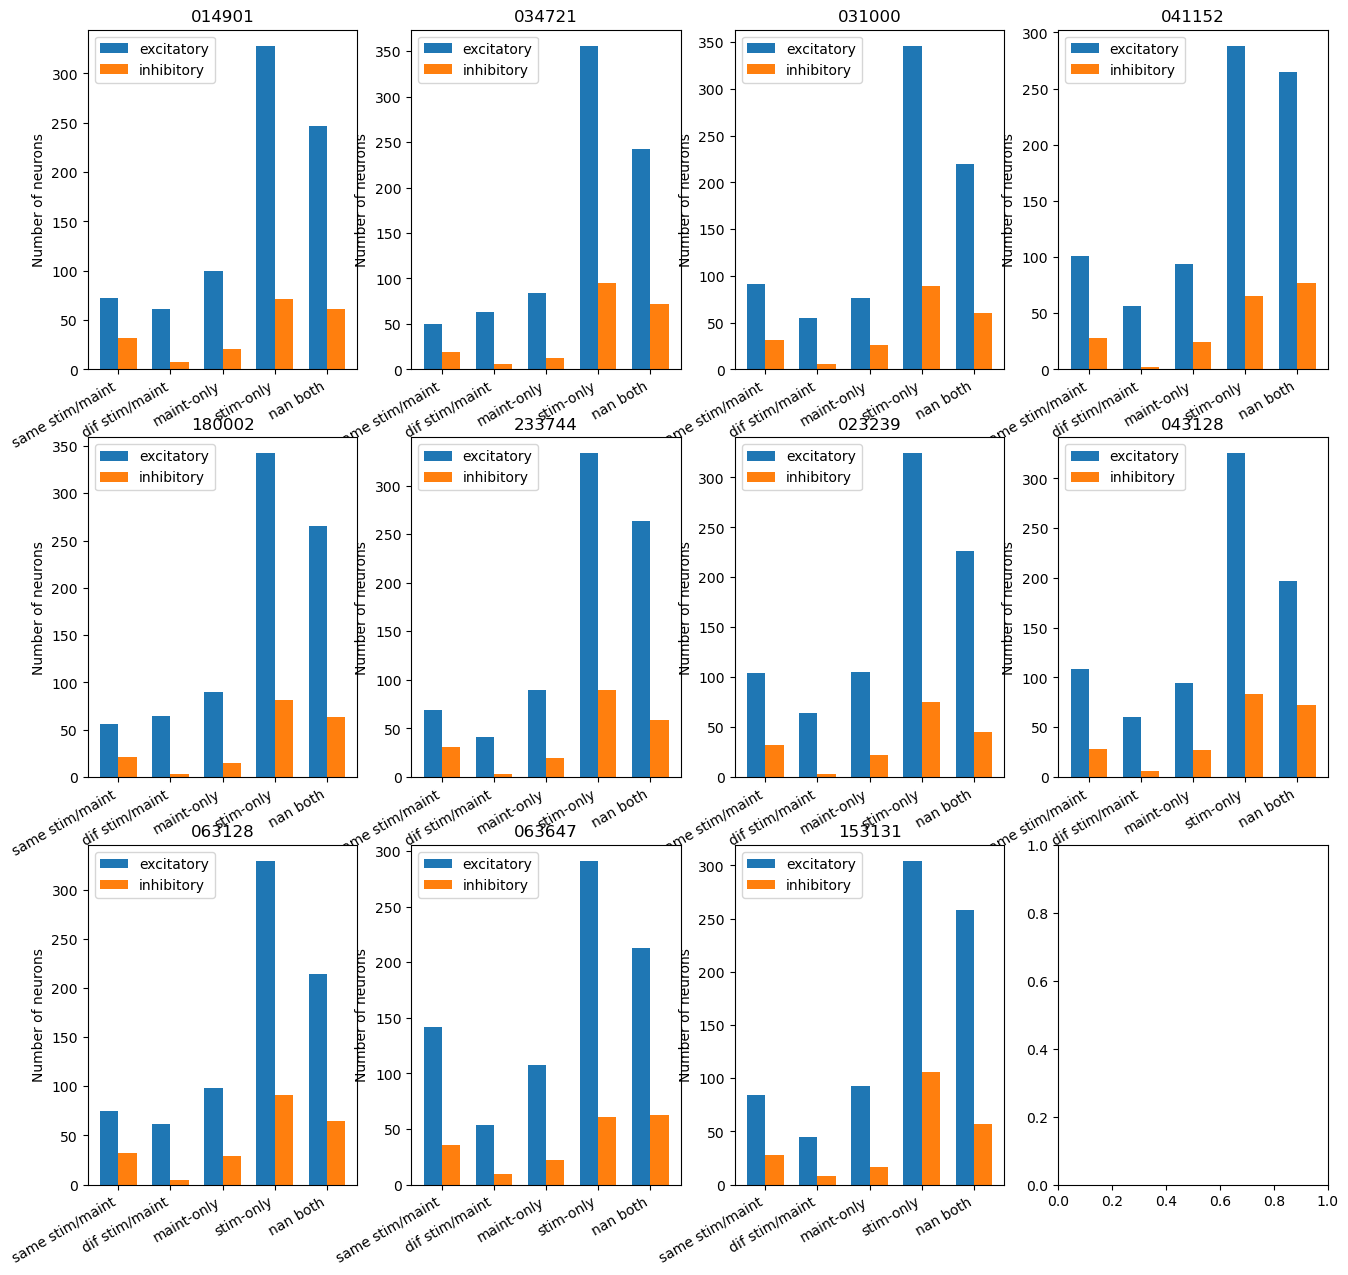

In [16]:
# for all models

fig, ax = plt.subplots(3, 4, figsize=(16,15))
ax = ax.flatten()
for i, model_name in enumerate(model_names):
    # check if stim1 stim-tuning and maintenance stim-tuning match

    model_dir = os.path.join(all_models_dir, model_name)
    stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']

    matching_idx = np.where(stim1_stimtuning == maint_stimtuning)[0]
    nonmatching_idx = np.where(stim1_stimtuning != maint_stimtuning)[0]
    # print(f'{len(matching_idx)} neurons have matching stim1 and maintenance tuning')
    # print(f'{len(nonmatching_idx)} neurons have non-matching stim1 and maintenance tuning')

    # how many are nan for one and non-nan for the other
    nan_stim1 = np.where(np.isnan(stim1_stimtuning))[0]
    nan_maint = np.where(np.isnan(maint_stimtuning))[0]
    nan_stim1_non_nan_maint = np.intersect1d(nan_stim1, np.setdiff1d(np.arange(len(stim1_stimtuning)), nan_maint))
    nan_maint_non_nan_stim1 = np.intersect1d(nan_maint, np.setdiff1d(np.arange(len(maint_stimtuning)), nan_stim1))
    # print(f'{len(nan_stim1_non_nan_maint)} neurons are nan for stim1 tuning but non-nan for maintenance tuning')
    # print(f'{len(nan_maint_non_nan_stim1)} neurons are nan for maintenance tuning but non-nan for stim1 tuning')

    # how many are both nan
    nan_both = np.intersect1d(nan_stim1, nan_maint)
    # print(f'{len(nan_both)} neurons are nan for both stim1 and maintenance tuning')

    # of the ones that are both tuned, how many have matching vs non-matching tuning
    both_tuned = np.intersect1d(np.setdiff1d(np.arange(len(stim1_stimtuning)), nan_stim1), np.setdiff1d(np.arange(len(maint_stimtuning)), nan_maint))
    matching_both_tuned = np.intersect1d(both_tuned, matching_idx)
    nonmatching_both_tuned = np.intersect1d(both_tuned, nonmatching_idx)
    # print(f'{len(matching_both_tuned)} neurons have matching stim1 and maintenance tuning and are both tuned')
    # print(f'{len(nonmatching_both_tuned)} neurons have non-matching stim1 and maintenance tuning and are both tuned')

    # make a barplot separating exc/inh of all of these types of neurons
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

    categories = ['same stim/maint', 'dif stim/maint', 'maint-only', 'stim-only', 'nan both']
    exc_counts = [len(np.intersect1d(exc_ind, matching_both_tuned)), len(np.intersect1d(exc_ind, nonmatching_both_tuned)), len(np.intersect1d(exc_ind, nan_stim1_non_nan_maint)), len(np.intersect1d(exc_ind, nan_maint_non_nan_stim1)), len(np.intersect1d(exc_ind, nan_both))]
    inh_counts = [len(np.intersect1d(inh_ind, matching_both_tuned)), len(np.intersect1d(inh_ind, nonmatching_both_tuned)), len(np.intersect1d(inh_ind, nan_stim1_non_nan_maint)), len(np.intersect1d(inh_ind, nan_maint_non_nan_stim1)), len(np.intersect1d(inh_ind, nan_both))]
    x = np.arange(len(categories))
    width = 0.35

    rects1 = ax[i].bar(x - width/2, exc_counts, width, label='excitatory')
    rects2 = ax[i].bar(x + width/2, inh_counts, width, label='inhibitory')
    ax[i].set_ylabel('Number of neurons')
    ax[i].set_title(f'{model_name[-6:]}')
    ax[i].set_xticks(x)
    ax[i].set_xticklabels(categories, rotation=30, ha='right')
    ax[i].legend()
plt.show()

Loading behavioral data...


/tmp/ipykernel_335681/2082887337.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(counts.keys(), rotation=30, ha='center')


Loading behavioral data...


/tmp/ipykernel_335681/2082887337.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(counts.keys(), rotation=30, ha='center')


Loading behavioral data...


...

/tmp/ipykernel_335681/2082887337.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(counts.keys(), rotation=30, ha='center')


Loading behavioral data...


/tmp/ipykernel_335681/2082887337.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(counts.keys(), rotation=30, ha='center')


Loading behavioral data...


/tmp/ipykernel_335681/2082887337.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(counts.keys(), rotation=30, ha='center')


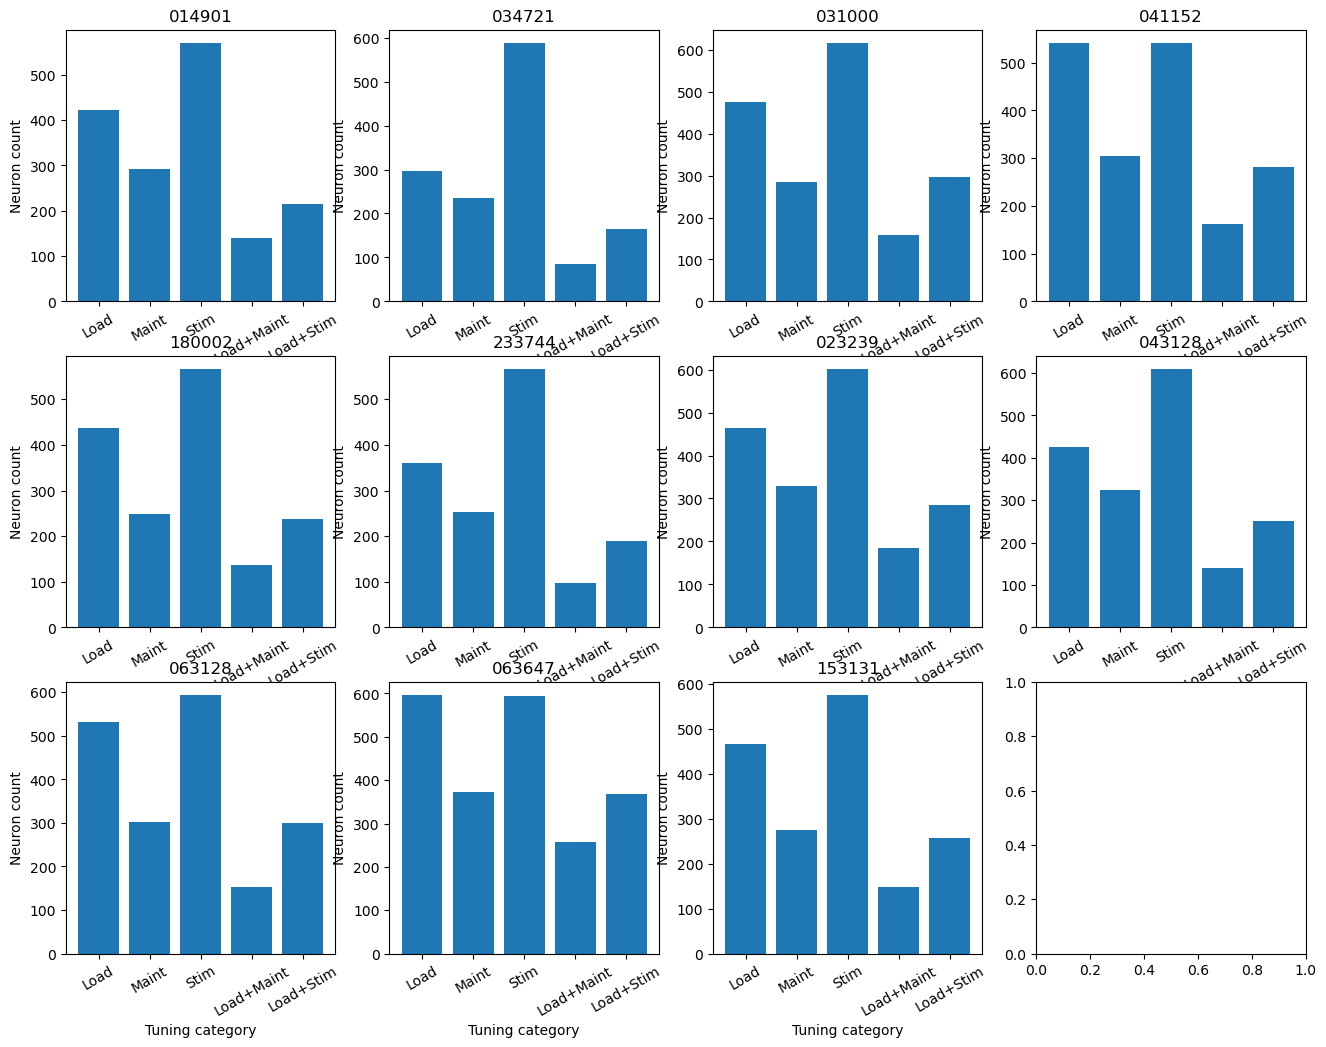

In [18]:
# for all models

fig, ax = plt.subplots(3, 4, figsize=(16,12))
ax = ax.flatten()
for i, model_name in enumerate(model_names):
    # check if stim1 stim-tuning and maintenance stim-tuning match

    model_dir = os.path.join(all_models_dir, model_name)
    stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']


    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                    other_labels = "balance_stims",
                                    all_models_dir=all_models_dir)

    # how many maintenance-tuned neurons are also load-tuned?
    load_tuned = np.where(~np.isnan(load_tuning))[0]
    maint_tuned = np.where(~np.isnan(maint_stimtuning))[0]
    stim_tuned = np.where(~np.isnan(stim1_stimtuning))[0]
    both_load_maint_tuned = np.intersect1d(load_tuned, maint_tuned)
    both_load_stim_tuned = np.intersect1d(load_tuned, stim_tuned)

    # print(f'{len(load_tuned)} neurons are load-tuned')
    # print(f'{len(stim_tuned)} neurons are stim-period stim-tuned')
    # print(f'{len(maint_tuned)} neurons are maintenance stim-tuned')
    # print(f'{len(both_load_maint_tuned)} neurons are both load-tuned and maintenance-tuned')
    # print(f'{len(both_load_stim_tuned)} neurons are both load-tuned and stim-tuned')

    counts = {
        "Load": len(load_tuned),
        "Maint": len(maint_tuned),
        "Stim": len(stim_tuned),
        "Load+Maint": len(both_load_maint_tuned),
        "Load+Stim": len(both_load_stim_tuned)
    }

    ax[i].bar(counts.keys(), counts.values())
    ax[i].set_xlabel("Tuning category")
    ax[i].set_ylabel("Neuron count")
    ax[i].set_title(f"{model_name[-6:]}")
    ax[i].set_xticklabels(counts.keys(), rotation=30, ha='center')

## didn't plot any below this

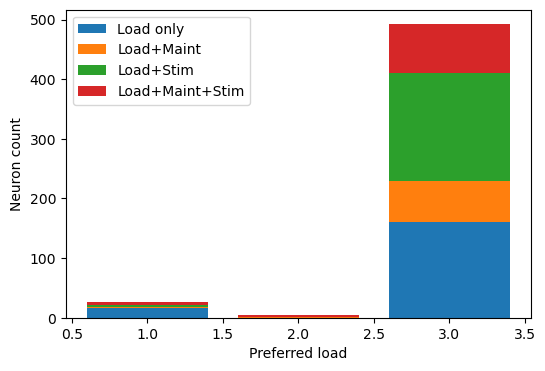

In [20]:
load_mask = ~np.isnan(load_tuning)
maint_mask = ~np.isnan(maint_stimtuning)
stim_mask = ~np.isnan(stim1_stimtuning)

loads = [1, 2, 3]

results = []

for load in loads:

    load_pref = (load_tuning == load)

    n_load_only = np.sum(
        load_pref &
        ~maint_mask &
        ~stim_mask
    )

    n_load_maint = np.sum(
        load_pref &
        maint_mask &
        ~stim_mask
    )

    n_load_stim = np.sum(
        load_pref &
        ~maint_mask &
        stim_mask
    )

    n_load_maint_stim = np.sum(
        load_pref &
        maint_mask &
        stim_mask
    )

    results.append([
        n_load_only,
        n_load_maint,
        n_load_stim,
        n_load_maint_stim
    ])
    
results = np.array(results)

plt.figure(figsize=(6,4))
plt.bar(loads, results[:,0], label='Load only')

plt.bar(
    loads,
    results[:,1],
    bottom=results[:,0],
    label='Load+Maint'
)

plt.bar(
    loads,
    results[:,2],
    bottom=results[:,0] + results[:,1],
    label='Load+Stim'
)

plt.bar(
    loads,
    results[:,3],
    bottom=results[:,0] + results[:,1] + results[:,2],
    label='Load+Maint+Stim'
)

plt.xlabel('Preferred load')
plt.ylabel('Neuron count')
plt.legend()
plt.show()

<Axes: xlabel='load', ylabel='count'>

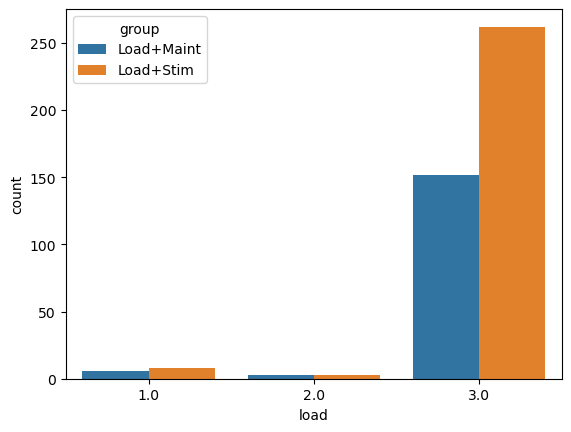

In [21]:
load_maint_pref = load_tuning[both_load_maint_tuned]
load_stim_pref = load_tuning[both_load_stim_tuned]

import pandas as pd

df = pd.DataFrame({
    "load": np.concatenate([load_maint_pref, load_stim_pref]),
    "group": (["Load+Maint"] * len(load_maint_pref) +
              ["Load+Stim"] * len(load_stim_pref))
})

import seaborn as sns

sns.countplot(
    data=df,
    x="load",
    hue="group"
)

### plot maint-selective firing rates, avg'd by stim, in load-3
look at maint-selective only neurons
- want to test the "additive" hypothesis of in a single trial, if stims are shown 1/2/3, does that just activate in sequence

In [22]:
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']
load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)

exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)


(780, 1000, 450)
Loading behavioral data...


In [23]:
matching_idx = np.where(stim1_stimtuning == maint_stimtuning)[0]
nonmatching_idx = np.where(stim1_stimtuning != maint_stimtuning)[0]

# how many are nan for one and non-nan for the other
nan_stim1 = np.where(np.isnan(stim1_stimtuning))[0]
nan_maint = np.where(np.isnan(maint_stimtuning))[0]
nan_stim1_non_nan_maint = np.intersect1d(nan_stim1, np.setdiff1d(np.arange(len(stim1_stimtuning)), nan_maint))
nan_maint_non_nan_stim1 = np.intersect1d(nan_maint, np.setdiff1d(np.arange(len(maint_stimtuning)), nan_stim1))
print(f'{len(nan_stim1_non_nan_maint)} neurons are nan for stim1 tuning but non-nan for maintenance tuning')
print(f'{len(nan_maint_non_nan_stim1)} neurons are nan for maintenance tuning but non-nan for stim1 tuning')

# how many are both nan
nan_both = np.intersect1d(nan_stim1, nan_maint)
print(f'{len(nan_both)} neurons are nan for both stim1 and maintenance tuning')

# of the ones that are both tuned, how many have matching vs non-matching tuning
both_tuned = np.intersect1d(np.setdiff1d(np.arange(len(stim1_stimtuning)), nan_stim1), np.setdiff1d(np.arange(len(maint_stimtuning)), nan_maint))
matching_both_tuned = np.intersect1d(both_tuned, matching_idx)
nonmatching_both_tuned = np.intersect1d(both_tuned, nonmatching_idx)

135 neurons are nan for stim1 tuning but non-nan for maintenance tuning
367 neurons are nan for maintenance tuning but non-nan for stim1 tuning
325 neurons are nan for both stim1 and maintenance tuning


#### plot mean fr of maint stim-tuned only neurons, split by stim1 tuning

##### plotting example neurons

/tmp/ipykernel_299703/2298349581.py:23: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_299703/2298349581.py:24: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


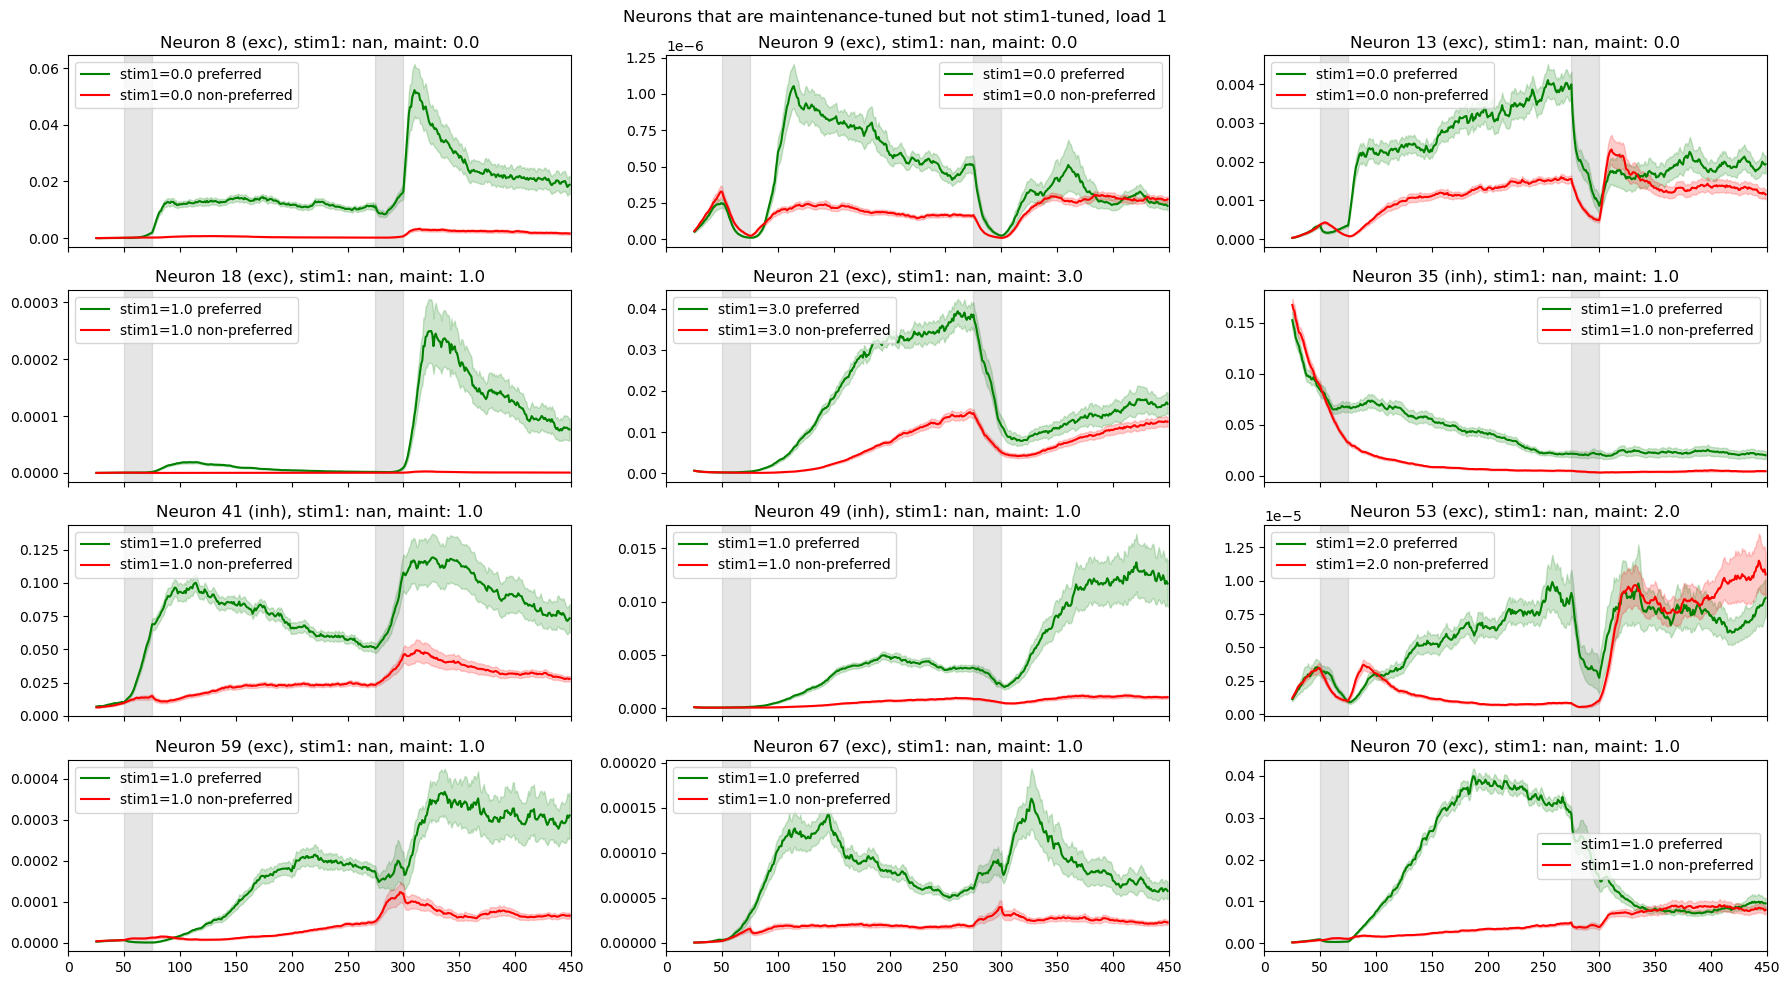

In [24]:
# LOAD 1
# plot mean fr of maint stim-tuned only neurons, split by stim1 tuning (indv neuron examples)

load = 1

# maint tuned, stim untuned
neuron_idxs = nan_stim1_non_nan_maint
suptitle_str = f'Neurons that are maintenance-tuned but not stim1-tuned, load {load}'

fig, axs = plt.subplots(4, 3, figsize=(18,10), sharex=True)
axs = axs.flatten()
colors = ['g','r']
for i, neuron_idx in enumerate(neuron_idxs[:np.amin([len(neuron_idxs), 12])]):  # plot at most 12 neurons
    ax = axs[i]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot load1 trial for stim1=preferred, and stim1=nonpreferred
    trial_idxs_pref = np.where(np.all(trial_labels[:,[0,2]] == [load, neuron_tuning], axis=1))[0]
    trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & (trial_labels[:,2] != neuron_tuning))[0]
    for j, trial_idxs in enumerate([trial_idxs_pref, trial_idxs_nonpref]):
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'stim1={neuron_tuning} {["preferred","non-preferred"][j]}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inh", "exc"][is_exc]}), stim1: {stim1_stimtuning[neuron_idx]}, maint: {maint_stimtuning[neuron_idx]}')

    ax.legend()
fig.suptitle(suptitle_str)
plt.tight_layout()
plt.show()

/tmp/ipykernel_299703/3660878936.py:29: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_299703/3660878936.py:30: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


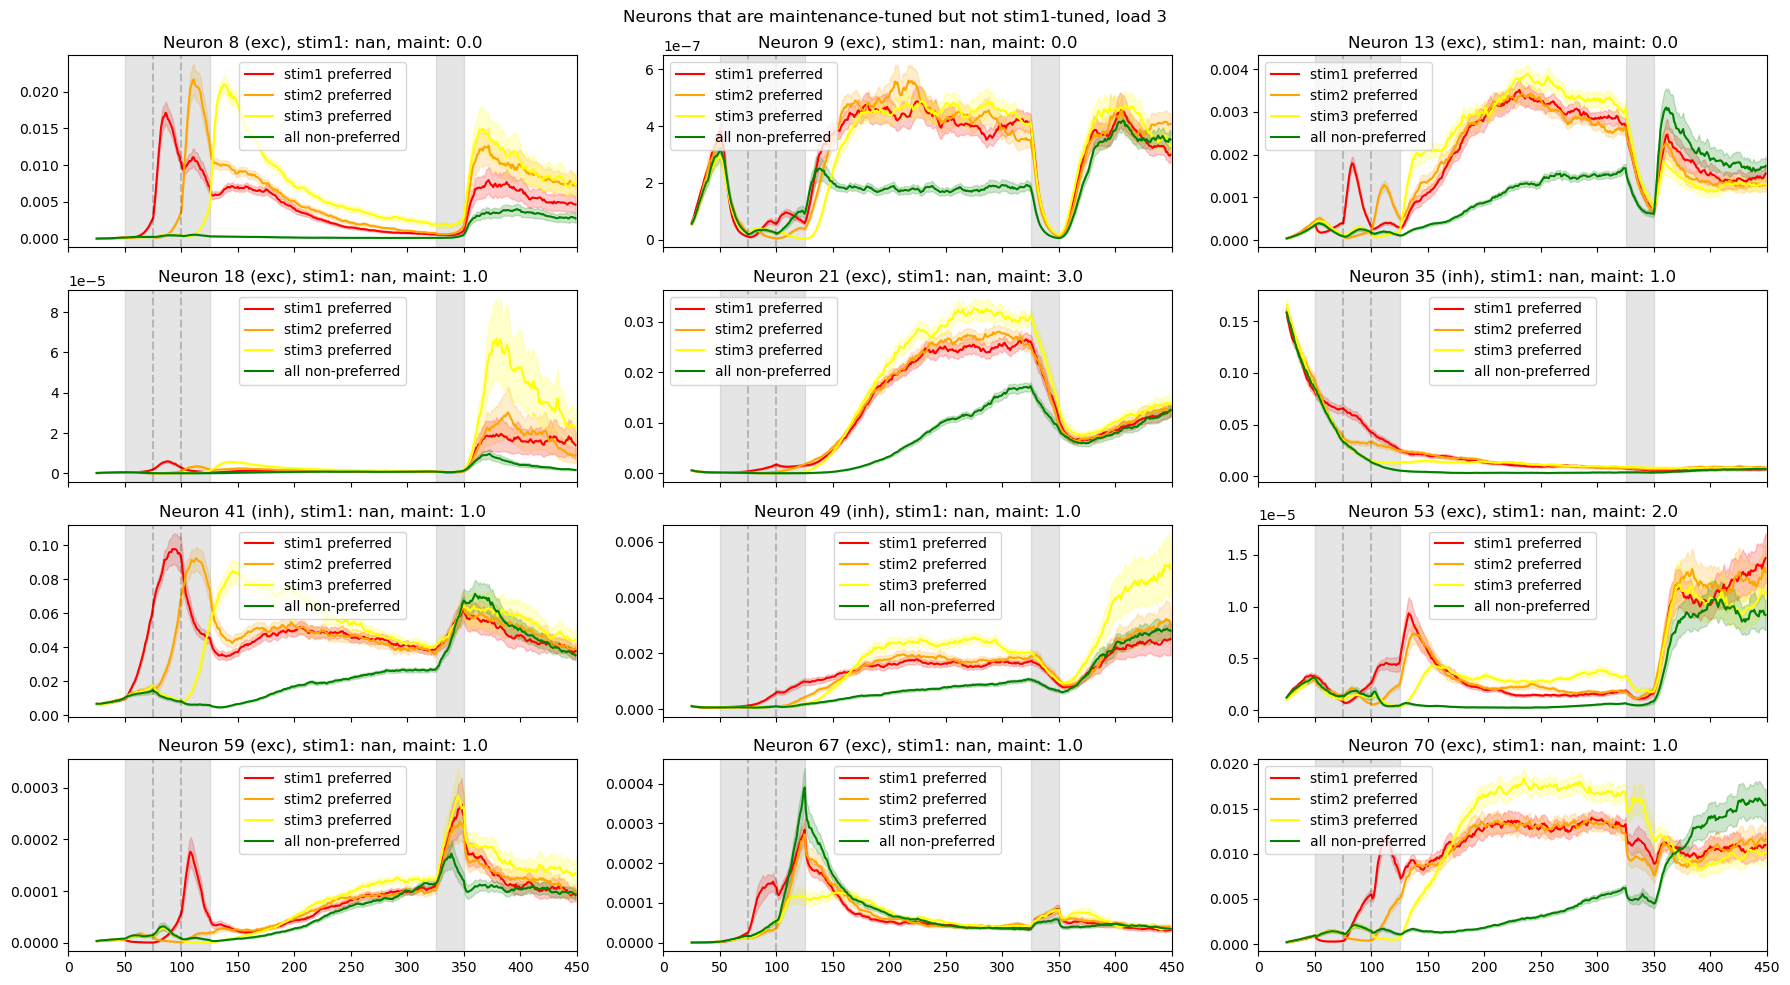

In [25]:
# LOAD 3
# plot mean fr of maint stim-tuned only neurons, split by stim1 tuning (indv neuron examples)

load = 3

# maint tuned, stim untuned
neuron_idxs = nan_stim1_non_nan_maint
suptitle_str = f'Neurons that are maintenance-tuned but not stim1-tuned, load {load}'

fig, axs = plt.subplots(4, 3, figsize=(18,10), sharex=True)
axs = axs.flatten()
colors = ['r','orange', 'yellow', 'g']
for i, neuron_idx in enumerate(neuron_idxs[:np.amin([len(neuron_idxs), 12])]):  # plot at most 12 neurons
    ax = axs[i]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot load-3 trial for stim1/2/3=preferred and rest=nonpreferred, and stim1/2/3=nonpreferred
    trial_idxs_pref1 = np.where(np.all(trial_labels[:,[0,2]] == [load, neuron_tuning], axis=1) & # stim1 is preferred
                               np.all(trial_labels[:,[3,4]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim2/3 are non-preferred
    trial_idxs_pref2 = np.where(np.all(trial_labels[:,[0,3]] == [load, neuron_tuning], axis=1) & # stim2 is preferred
                               np.all(trial_labels[:,[2,4]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim1/3 are non-preferred
    trial_idxs_pref3 = np.where(np.all(trial_labels[:,[0,4]] == [load, neuron_tuning], axis=1) & # stim3 is preferred
                               np.all(trial_labels[:,[2,3]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim1/2 are non-preferred
    trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & # correct load
                                  np.all(trial_labels[:,[2,3,4]] != [neuron_tuning, neuron_tuning, neuron_tuning], axis=1))[0] # stim1/2/3 are non-preferred
    for j, trial_idxs in enumerate([trial_idxs_pref1, trial_idxs_pref2, trial_idxs_pref3, trial_idxs_nonpref]):
        trial_rate = rates_data[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        if j < 3:
            ax.plot(mean_rate, label=f'stim{["1","2","3"][j]} preferred', color = colors[j])
        else:
            ax.plot(mean_rate, label=f'all non-preferred', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inh", "exc"][is_exc]}), stim1: {stim1_stimtuning[neuron_idx]}, maint: {maint_stimtuning[neuron_idx]}')
    ax.legend()
fig.suptitle(suptitle_str)
plt.tight_layout()
plt.show()

##### mini attempt at baselining the rates

In [24]:
def zscore_rates(rates, baseline=[25,50]):
    # rates is (n_trials, n_neurons, n_timebins)
    # z-score across neurons, such that each neuron's activity is normalized by its own mean and std across all trials during baseline timebin
    
    baseline_rates = rates[:,:,baseline[0]:baseline[1]]  # (n_trials, n_neurons, n_baseline_timebins)
    
    # mean for each neuron across all trials and baseline timebins
    mean_baseline = np.nanmean(baseline_rates, axis=(0,2))  # std for each neuron across all trials and baseline timebins
    std_baseline = np.nanstd(baseline_rates, axis=(0,2))
    
    # z-score the rates
    rates_zscore = (rates - mean_baseline[None,:,None]) / std_baseline[None,:,None]
    
    return rates_zscore

In [25]:
rates_data_nan = rates_data.copy()
rates_data_nan[:,:,:25] = np.nan  # mask out the first 25 time bins to remove noise
rates_data_zscored = zscore_rates(rates_data_nan, baseline=[25,50])

/tmp/ipykernel_31956/3615169938.py:23: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_31956/3615169938.py:24: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


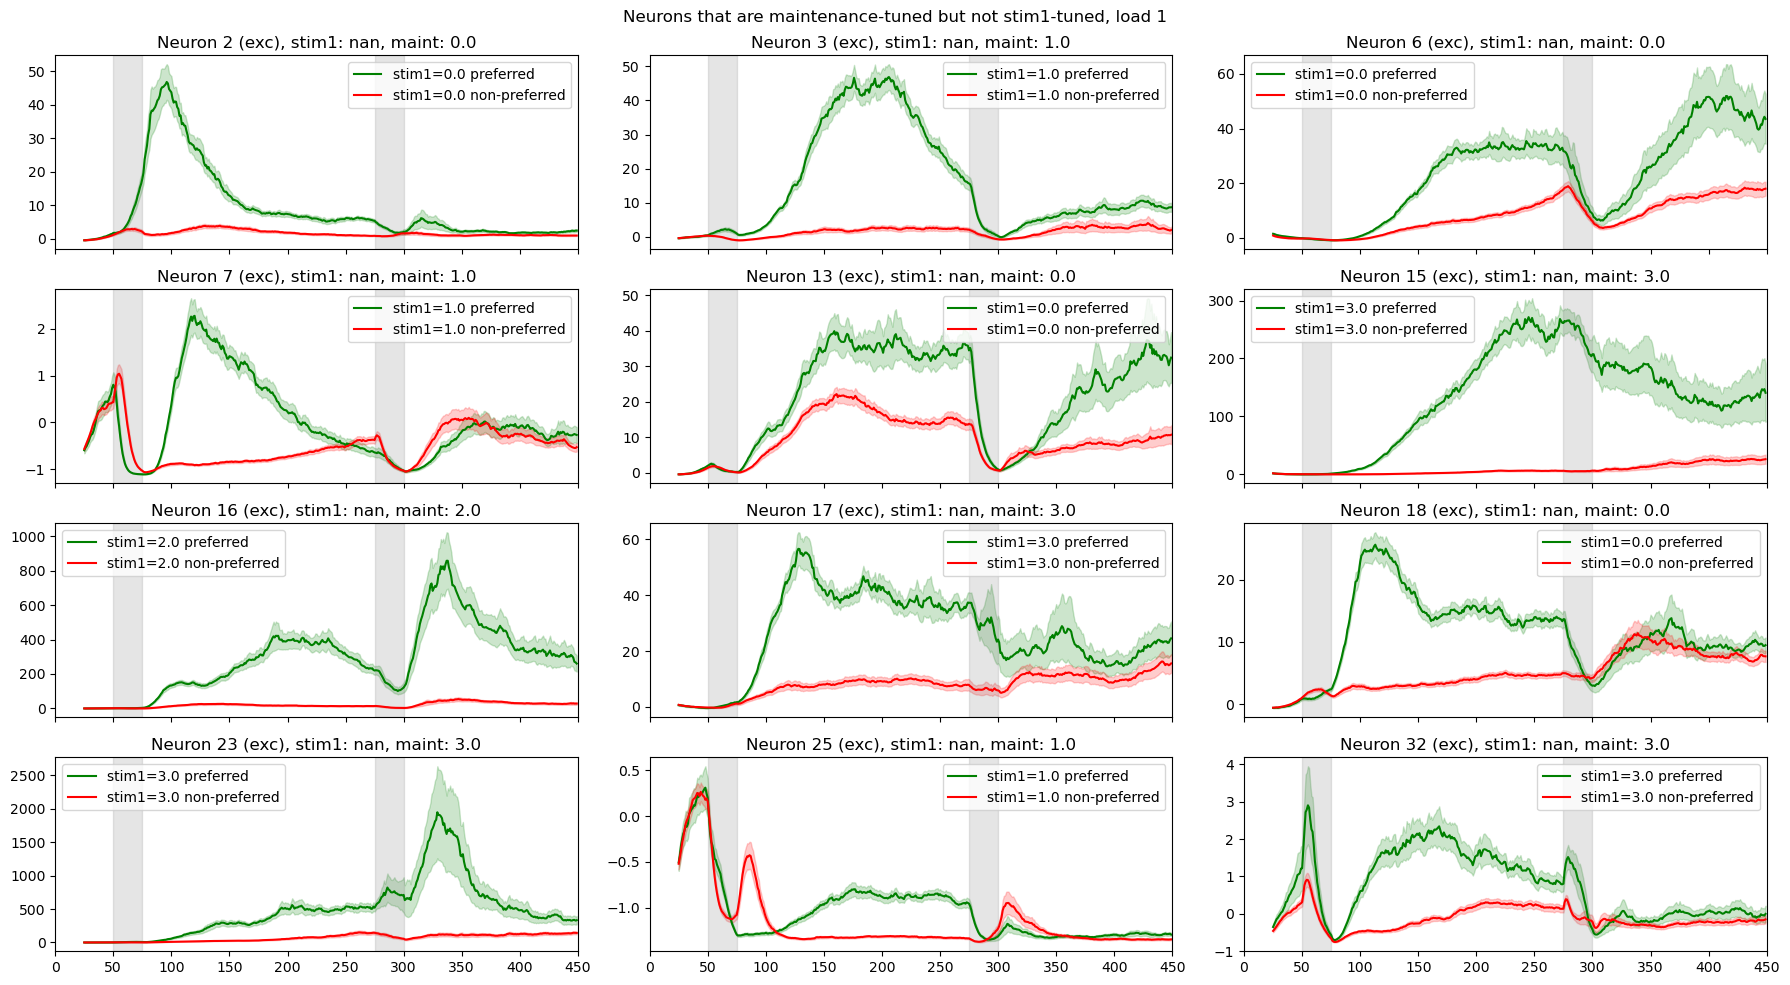

In [26]:
# LOAD 1
# plot mean fr of maint stim-tuned only neurons, split by stim1 tuning (indv neuron examples)

load = 1

# maint tuned, stim untuned
neuron_idxs = nan_stim1_non_nan_maint
suptitle_str = f'Neurons that are maintenance-tuned but not stim1-tuned, load {load}'

fig, axs = plt.subplots(4, 3, figsize=(18,10), sharex=True)
axs = axs.flatten()
colors = ['g','r']
for i, neuron_idx in enumerate(neuron_idxs[:np.amin([len(neuron_idxs), 12])]):  # plot at most 12 neurons
    ax = axs[i]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot load1 trial for stim1=preferred, and stim1=nonpreferred
    trial_idxs_pref = np.where(np.all(trial_labels[:,[0,2]] == [load, neuron_tuning], axis=1))[0]
    trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & (trial_labels[:,2] != neuron_tuning))[0]
    for j, trial_idxs in enumerate([trial_idxs_pref, trial_idxs_nonpref]):
        trial_rate = rates_data_zscored[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'stim1={neuron_tuning} {["preferred","non-preferred"][j]}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inh", "exc"][is_exc]}), stim1: {stim1_stimtuning[neuron_idx]}, maint: {maint_stimtuning[neuron_idx]}')

    ax.legend()
fig.suptitle(suptitle_str)
plt.tight_layout()
plt.show()

In [ ]:
def dividemean_rates(rates, baseline=[25,50]):
    # rates is (n_trials, n_neurons, n_timebins)
    # z-score across neurons, such that each neuron's activity is divided by its own mean across all trials during baseline timebin
    
    baseline_rates = rates[:,:,baseline[0]:baseline[1]]  # (n_trials, n_neurons, n_baseline_timebins)
    
    # mean for each neuron across all trials and baseline timebins
    mean_baseline = np.nanmean(baseline_rates, axis=(0,2))  # std for each neuron across all trials and baseline timebins
    # std_baseline = np.nanstd(baseline_rates, axis=(0,2))
    
    # z-score the rates
    rates_dmean = rates / mean_baseline[None,:,None]
    
    return rates_dmean

In [32]:
rates_data_nan = rates_data.copy()
rates_data_nan[:,:,:25] = np.nan  # mask out the first 25 time bins to remove noise
rates_data_dmean = dividemean_rates(rates_data_nan, baseline=[25,50])

/tmp/ipykernel_31956/1816910124.py:23: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_31956/1816910124.py:24: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


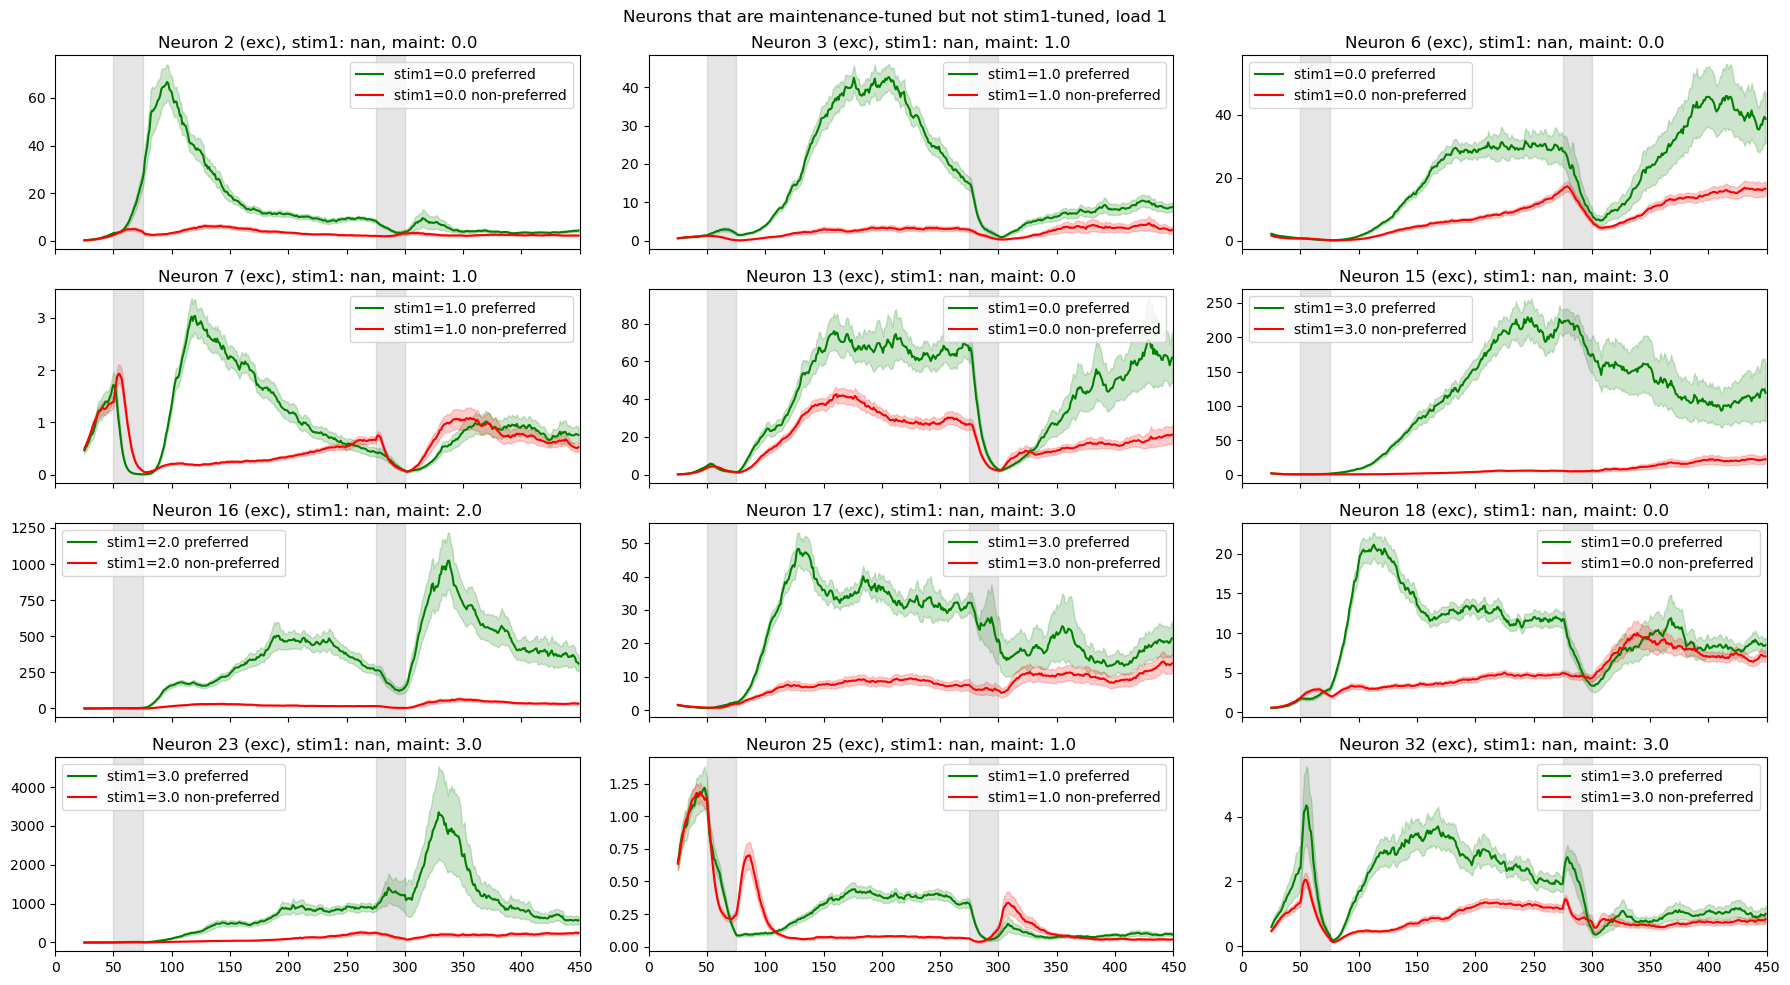

In [33]:
# LOAD 1
# plot mean fr of maint stim-tuned only neurons, split by stim1 tuning (indv neuron examples)

load = 1

# maint tuned, stim untuned
neuron_idxs = nan_stim1_non_nan_maint
suptitle_str = f'Neurons that are maintenance-tuned but not stim1-tuned, load {load}'

fig, axs = plt.subplots(4, 3, figsize=(18,10), sharex=True)
axs = axs.flatten()
colors = ['g','r']
for i, neuron_idx in enumerate(neuron_idxs[:np.amin([len(neuron_idxs), 12])]):  # plot at most 12 neurons
    ax = axs[i]
    neuron_tuning = stim1_tuning[neuron_idx]
    is_exc = [1 if neuron_idx in exc_ind else 0][0]
    # plot load1 trial for stim1=preferred, and stim1=nonpreferred
    trial_idxs_pref = np.where(np.all(trial_labels[:,[0,2]] == [load, neuron_tuning], axis=1))[0]
    trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & (trial_labels[:,2] != neuron_tuning))[0]
    for j, trial_idxs in enumerate([trial_idxs_pref, trial_idxs_nonpref]):
        trial_rate = rates_data_dmean[trial_idxs, neuron_idx, :]
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'stim1={neuron_tuning} {["preferred","non-preferred"][j]}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Neuron {neuron_idx} ({["inh", "exc"][is_exc]}), stim1: {stim1_stimtuning[neuron_idx]}, maint: {maint_stimtuning[neuron_idx]}')

    ax.legend()
fig.suptitle(suptitle_str)
plt.tight_layout()
plt.show()

##### plotting means now

/tmp/ipykernel_299703/3695981500.py:25: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_299703/3695981500.py:26: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


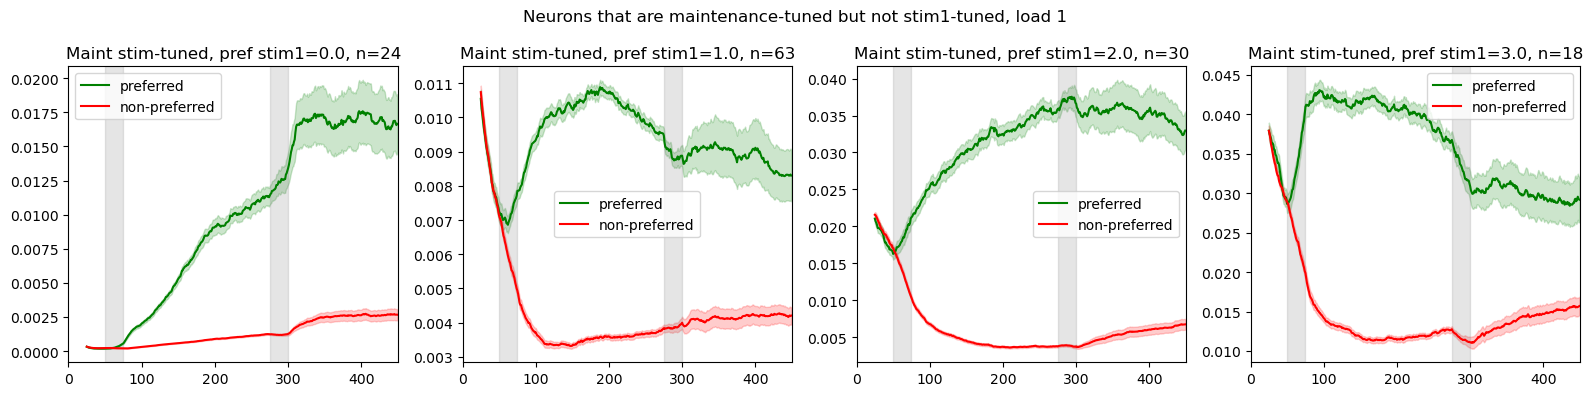

In [26]:
# LOAD 1
# plot mean fr of maint stim-tuned only neurons, split by stim1 tuning (mean of groups)

load = 1

# maint tuned, stim untuned
neuron_idxs = nan_stim1_non_nan_maint
neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
stim1s = np.unique(neuron_idxs_tuning)
suptitle_str = f'Neurons that are maintenance-tuned but not stim1-tuned, load {load}'

fig, axs = plt.subplots(1, 4, figsize=(16,4), sharex=True)
axs = axs.flatten()
colors = ['g','r']
for i, stim_id in enumerate(stim1s): 
    ax = axs[i]
    these_neuron_idxs = neuron_idxs[neuron_idxs_tuning == stim_id]
    # plot load1 trial for stim1=preferred, and stim1=nonpreferred
    trial_idxs_pref = np.where(np.all(trial_labels[:,[0,2]] == [load, stim_id], axis=1))[0]
    trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & (trial_labels[:,2] != stim_id))[0]
    for j, trial_idxs in enumerate([trial_idxs_pref, trial_idxs_nonpref]):
        trial_rates_ofinterest = rates_data[trial_idxs, :, :]
        trial_rate = np.mean(trial_rates_ofinterest[:, these_neuron_idxs, :], axis=1) # mean over neurons with same stim1 tuning during maintenance
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        ax.plot(mean_rate, label=f'{["preferred","non-preferred"][j]}', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Maint stim-tuned, pref stim1={stim_id}, n={len(these_neuron_idxs)}')

    ax.legend()
fig.suptitle(suptitle_str)
plt.tight_layout()
plt.show()

/tmp/ipykernel_299703/580904561.py:31: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_299703/580904561.py:32: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


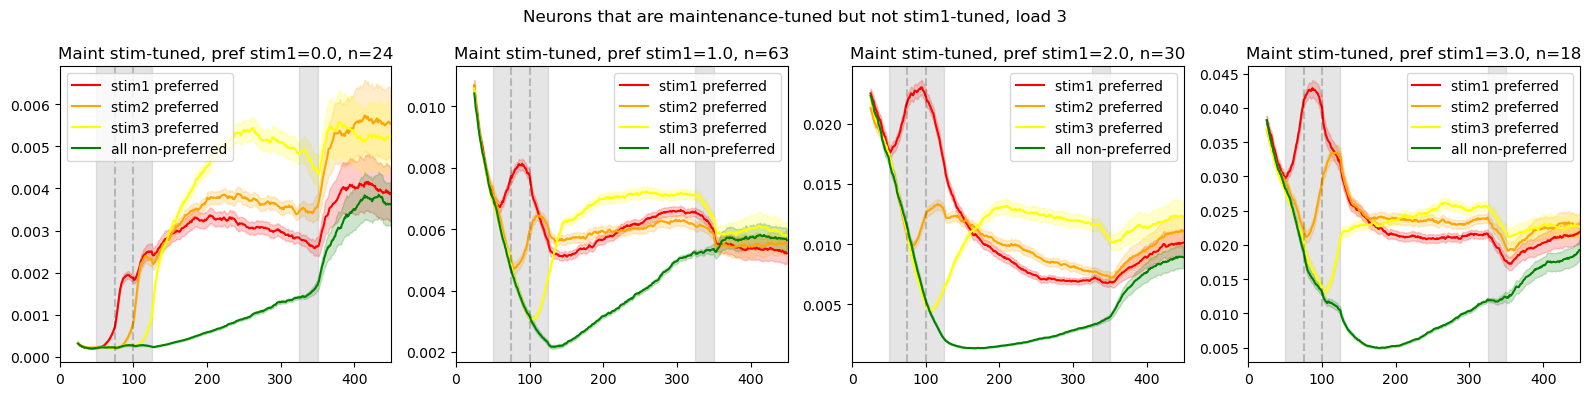

In [27]:
# LOAD 3
# plot mean fr of maint stim-tuned only neurons, split by stim1 tuning (indv neuron examples)

load = 3

# maint tuned, stim untuned
neuron_idxs = nan_stim1_non_nan_maint
stim1s = np.unique(maint_stimtuning[neuron_idxs])
suptitle_str = f'Neurons that are maintenance-tuned but not stim1-tuned, load {load}'

fig, axs = plt.subplots(1, 4, figsize=(16,4), sharex=True)
axs = axs.flatten()
colors = ['r','orange', 'yellow', 'g']
for i, neuron_tuning in enumerate(stim1s): 
    ax = axs[i]
    these_neuron_idxs = neuron_idxs[maint_stimtuning[neuron_idxs] == neuron_tuning]
    
    # plot load-3 trial for stim1/2/3=preferred and rest=nonpreferred, and stim1/2/3=nonpreferred
    trial_idxs_pref1 = np.where(np.all(trial_labels[:,[0,2]] == [load, neuron_tuning], axis=1) & # stim1 is preferred
                               np.all(trial_labels[:,[3,4]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim2/3 are non-preferred
    trial_idxs_pref2 = np.where(np.all(trial_labels[:,[0,3]] == [load, neuron_tuning], axis=1) & # stim2 is preferred
                               np.all(trial_labels[:,[2,4]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim1/3 are non-preferred
    trial_idxs_pref3 = np.where(np.all(trial_labels[:,[0,4]] == [load, neuron_tuning], axis=1) & # stim3 is preferred
                               np.all(trial_labels[:,[2,3]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim1/2 are non-preferred
    trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & # correct load
                                  np.all(trial_labels[:,[2,3,4]] != [neuron_tuning, neuron_tuning, neuron_tuning], axis=1))[0] # stim1/2/3 are non-preferred
    for j, trial_idxs in enumerate([trial_idxs_pref1, trial_idxs_pref2, trial_idxs_pref3, trial_idxs_nonpref]):
        trial_rates_ofinterest = rates_data[trial_idxs, :, :]
        trial_rate = np.mean(trial_rates_ofinterest[:, these_neuron_idxs, :], axis=1) # mean over neurons with same stim1 tuning during maintenance
        trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
        mean_rate = np.nanmean(trial_rate, axis=0)
        sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
        if j < 3:
            ax.plot(mean_rate, label=f'stim{["1","2","3"][j]} preferred', color = colors[j])
        else:
            ax.plot(mean_rate, label=f'all non-preferred', color = colors[j])
        ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
    ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
    for k in range(load-1):
        ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
    ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                color='gray', alpha=0.2)
    ax.set_xlim([0, 450])
    ax.set_title(f'Maint stim-tuned, pref stim1={neuron_tuning}, n={len(these_neuron_idxs)}')
    ax.legend()
fig.suptitle(suptitle_str)
plt.tight_layout()
plt.show()

/tmp/ipykernel_299703/330047315.py:30: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_299703/330047315.py:31: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


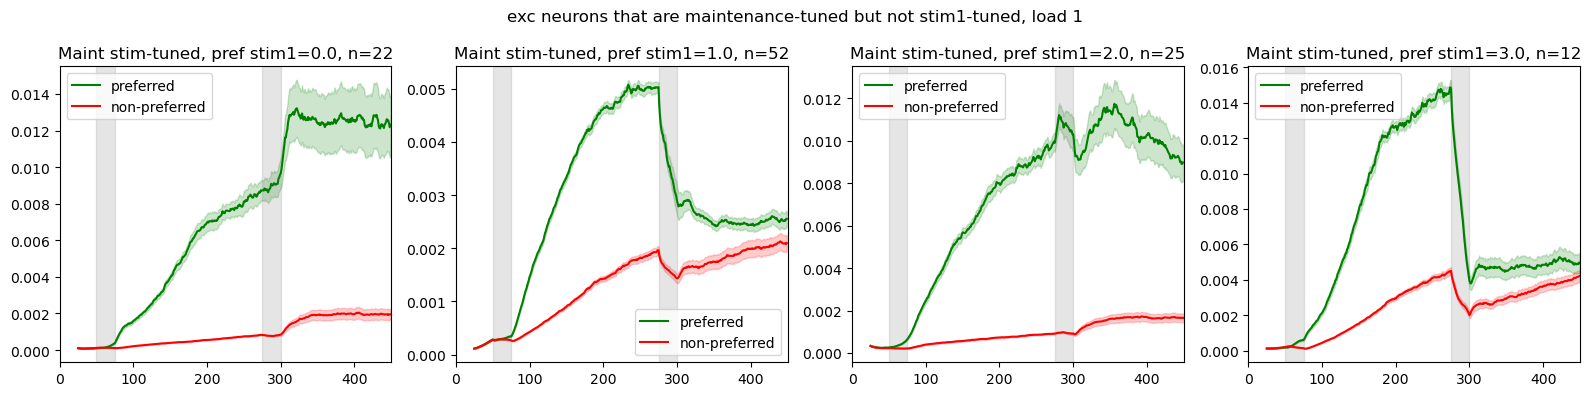

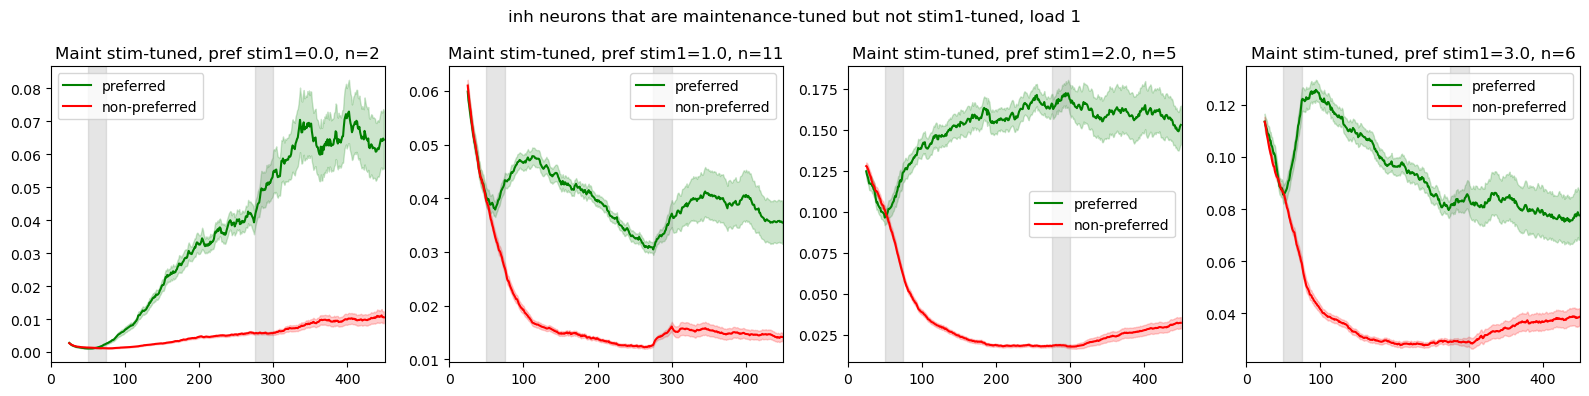

In [28]:
# LOAD 1
# plot mean fr of maint stim-tuned only neurons, split by stim1 tuning (mean of groups)

load = 1

# maint tuned, stim untuned
neuron_idxs = nan_stim1_non_nan_maint
neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
stim1s = np.unique(neuron_idxs_tuning)

# plot exc and inh separately
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

for neuron_inds in [np.intersect1d(neuron_idxs, exc_ind), np.intersect1d(neuron_idxs, inh_ind)]:
    suptitle_str = f'{["exc", "inh"][int(neuron_inds[0] in inh_ind)]} neurons that are maintenance-tuned but not stim1-tuned, load {load}'

    fig, axs = plt.subplots(1, 4, figsize=(16,4), sharex=True)
    axs = axs.flatten()
    colors = ['g','r']
    for i, stim_id in enumerate(stim1s): 
        ax = axs[i]
        these_neuron_idxs = np.intersect1d(neuron_idxs[neuron_idxs_tuning == stim_id], neuron_inds)
        # plot load1 trial for stim1=preferred, and stim1=nonpreferred
        trial_idxs_pref = np.where(np.all(trial_labels[:,[0,2]] == [load, stim_id], axis=1))[0]
        trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & (trial_labels[:,2] != stim_id))[0]
        for j, trial_idxs in enumerate([trial_idxs_pref, trial_idxs_nonpref]):
            trial_rates_ofinterest = rates_data[trial_idxs, :, :]
            trial_rate = np.mean(trial_rates_ofinterest[:, these_neuron_idxs, :], axis=1) # mean over neurons with same stim1 tuning during maintenance
            trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
            mean_rate = np.nanmean(trial_rate, axis=0)
            sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
            ax.plot(mean_rate, label=f'{["preferred","non-preferred"][j]}', color = colors[j])
            ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
        ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
        ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                    color='gray', alpha=0.2)
        ax.set_xlim([0, 450])
        ax.set_title(f'Maint stim-tuned, pref stim1={stim_id}, n={len(these_neuron_idxs)}')

        ax.legend()
    fig.suptitle(suptitle_str)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_299703/4270095891.py:36: RuntimeWarning: Mean of empty slice
  mean_rate = np.nanmean(trial_rate, axis=0)
/tmp/ipykernel_299703/4270095891.py:37: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')


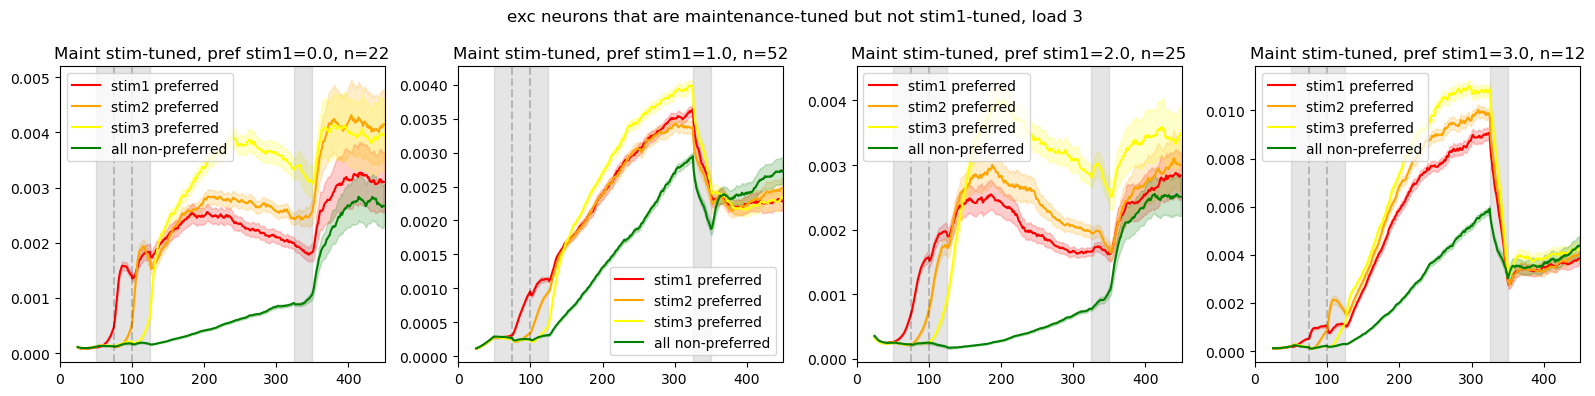

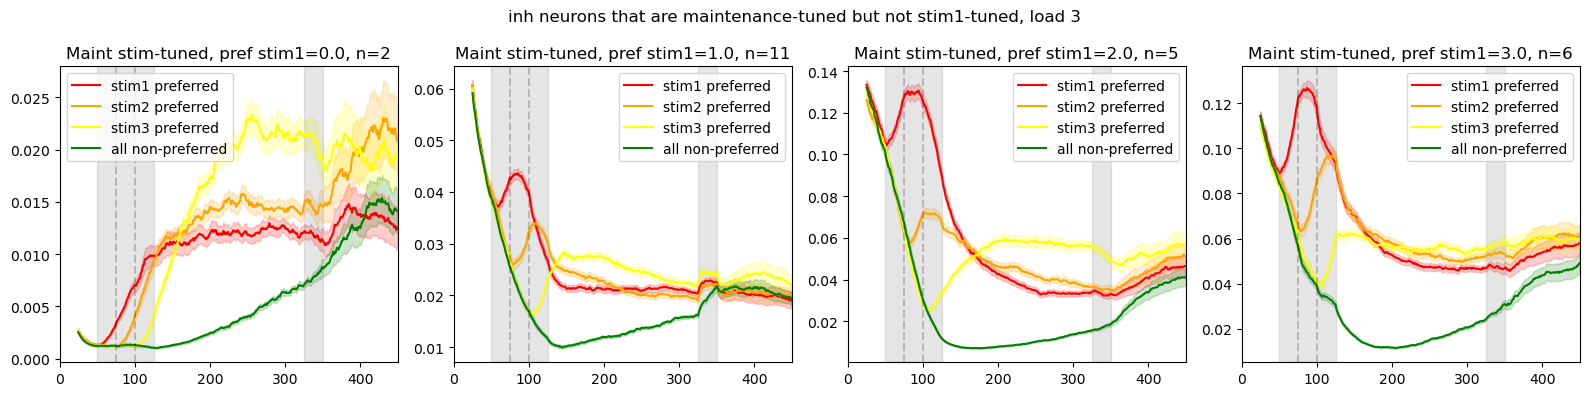

In [29]:
# LOAD 3
# plot mean fr of maint stim-tuned only neurons, split by stim1 tuning (indv neuron examples)

load = 3

# maint tuned, stim untuned
neuron_idxs = nan_stim1_non_nan_maint
neuron_idxs_tuning = maint_stimtuning[neuron_idxs]
stim1s = np.unique(neuron_idxs_tuning)

# plot exc and inh separately
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)

for neuron_inds in [np.intersect1d(neuron_idxs, exc_ind), np.intersect1d(neuron_idxs, inh_ind)]:
    suptitle_str = f'{["exc", "inh"][int(neuron_inds[0] in inh_ind)]} neurons that are maintenance-tuned but not stim1-tuned, load {load}'
    fig, axs = plt.subplots(1, 4, figsize=(16,4), sharex=True)
    axs = axs.flatten()
    colors = ['r','orange', 'yellow', 'g']
    for i, neuron_tuning in enumerate(stim1s):
        ax = axs[i]
        these_neuron_idxs = np.intersect1d(neuron_idxs[maint_stimtuning[neuron_idxs] == neuron_tuning], neuron_inds)
        
        # plot load-3 trial for stim1/2/3=preferred and rest=nonpreferred, and stim1/2/3=nonpreferred
        trial_idxs_pref1 = np.where(np.all(trial_labels[:,[0,2]] == [load, neuron_tuning], axis=1) & # stim1 is preferred
                                np.all(trial_labels[:,[3,4]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim2/3 are non-preferred
        trial_idxs_pref2 = np.where(np.all(trial_labels[:,[0,3]] == [load, neuron_tuning], axis=1) & # stim2 is preferred
                                np.all(trial_labels[:,[2,4]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim1/3 are non-preferred
        trial_idxs_pref3 = np.where(np.all(trial_labels[:,[0,4]] == [load, neuron_tuning], axis=1) & # stim3 is preferred
                                np.all(trial_labels[:,[2,3]] != [neuron_tuning, neuron_tuning], axis=1))[0] # stim1/2 are non-preferred
        trial_idxs_nonpref = np.where((trial_labels[:,0] == load) & # correct load
                                    np.all(trial_labels[:,[2,3,4]] != [neuron_tuning, neuron_tuning, neuron_tuning], axis=1))[0] # stim1/2/3 are non-preferred
        for j, trial_idxs in enumerate([trial_idxs_pref1, trial_idxs_pref2, trial_idxs_pref3, trial_idxs_nonpref]):
            trial_rates_ofinterest = rates_data[trial_idxs, :, :]
            trial_rate = np.mean(trial_rates_ofinterest[:, these_neuron_idxs, :], axis=1) # mean over neurons with same stim1 tuning during maintenance
            trial_rate[:,:25] = np.nan  # mask out the first 25 time bins to remove noise
            mean_rate = np.nanmean(trial_rate, axis=0)
            sem_rate = scipy.stats.sem(trial_rate, axis=0, nan_policy='omit')
            if j < 3:
                ax.plot(mean_rate, label=f'stim{["1","2","3"][j]} preferred', color = colors[j])
            else:
                ax.plot(mean_rate, label=f'all non-preferred', color = colors[j])
            ax.fill_between(np.arange(len(mean_rate)), mean_rate - sem_rate, mean_rate + sem_rate, color = colors[j], alpha=0.2)
        ax.axvspan(settings['stim_on'], settings['stim_on'] + settings['stim_dur']*load, color='gray', alpha=0.2)
        for k in range(load-1):
            ax.axvline(settings['stim_on'] + settings['stim_dur']*(k+1), color='black', alpha=0.2, linestyle='--')
        ax.axvspan(settings['stim_on'] + settings['stim_dur']*load + settings['delay'], settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur'], 
                    color='gray', alpha=0.2)
        ax.set_xlim([0, 450])
        ax.set_title(f'Maint stim-tuned, pref stim1={neuron_tuning}, n={len(these_neuron_idxs)}')
        ax.legend()
    fig.suptitle(suptitle_str)
    plt.tight_layout()
    plt.show()